In [2]:
from pathlib import Path

import pandas as pd
import numpy as np


def resolve_meps_dir() -> Path:
    """Walk up from CWD looking for data/MEPS/(excels/)? that contains h248a.xlsx.

    Works whether the kernel CWD is the repo root, Notebooks/, or Notebooks/MEPS/.
    """
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data" / "MEPS" / "excels",
        cwd / "data" / "MEPS",
        cwd / "MEPS" / "excels",
        cwd / "MEPS",
        cwd,
        cwd.parent / "data" / "MEPS" / "excels",
        cwd.parent / "data" / "MEPS",
        cwd.parent.parent / "data" / "MEPS" / "excels",
        cwd.parent.parent / "data" / "MEPS",
        cwd.parent.parent.parent / "data" / "MEPS" / "excels",
        cwd.parent.parent.parent / "data" / "MEPS",
    ]
    for d in candidates:
        if d.exists() and any(d.glob("h248a.xlsx")):
            return d
    return candidates[0]


MEPS_DIR = resolve_meps_dir()
print(f"MEPS directory: {MEPS_DIR}")


MEPS directory: /Users/friana/Medical Adherence/data/MEPS


In [3]:
df_248 = pd.read_excel(MEPS_DIR / "h248a.xlsx")

In [4]:
pd.set_option('display.max_columns', None)
df_248.head()

,DUID,PID,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PANEL,PURCHRD,RXBEGMM,RXBEGYRX,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXFRMUNT,RXSTRENG,RXSTRUNT,RXDAYSUP,PHARTP1,PHARTP2,PHARTP3,PHARTP4,PHARTP5,PHARTP6,RXFLG,IMPFLAG,PCIMPFLG,DIABEQUIP,INPCFLG,TC1,TC1S1,TC1S1_1,TC1S1_2,TC1S2,TC1S2_1,TC1S3,TC1S3_1,TC2,TC2S1,TC2S1_1,TC2S1_2,TC2S2,TC3,TC3S1,TC3S1_1,RXSF23X,RXMR23X,RXMD23X,RXPV23X,RXVA23X,RXTR23X,RXOF23X,RXSL23X,RXWC23X,RXOT23X,RXXP23X,PERWT23F,VARSTR,VARPSU
0,2790002,101,2790002101,2790002101002,2790002101002303001,2790002101002303,27,3,-1,-1,BD PEN NEEDL,-15,8290320550,100.0,MISC,EA,-15,-15,-8,4,-1,-1,-1,-1,-1,1,4,2,1,1,-15,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,13.00,0.0,0.0,41.78,0.0,0.0,0.0,0.0,0.0,0.0,54.78,11664.426815,2019,1
1,2790002,101,2790002101,2790002101006,2790002101006403001,2790002101006403,27,4,5,2023,PREDNISONE,PREDNISONE,591544210,40.0,TABS,EA,10,MG,16,4,4,-1,-1,-1,-1,1,2,1,2,1,97,98,301,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,7.20,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,7.20,11664.426815,2019,1
2,2790002,101,2790002101,2790002101007,2790002101007403001,2790002101007403,27,4,7,2023,PREDNISONE,PREDNISONE,70954006020,10.0,TABS,EA,20,MG,5,4,4,-1,-1,-1,-1,1,5,1,2,1,97,98,301,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,2.39,0.0,0.0,10.93,0.0,0.0,0.0,0.0,0.0,0.0,13.32,11664.426815,2019,1
3,2790002,101,2790002101,2790002101008,2790002101008403001,2790002101008403,27,4,-15,2020,METFORMIN,METFORMIN,70010006305,60.0,TABS,EA,500,MG,30,4,4,-1,-1,-1,-1,1,2,1,2,1,358,99,214,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,6.22,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,6.22,11664.426815,2019,1
4,2790002,101,2790002101,2790002101008,2790002101008403002,2790002101008403,27,4,-15,2020,METFORMIN,METFORMIN,378718505,60.0,TABS,EA,500,MG,30,4,4,-1,-1,-1,-1,1,2,1,2,1,358,99,214,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,6.22,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,6.22,11664.426815,2019,1


In [5]:
clean_df = df_248[["DUPERSID","DRUGIDX","LINKIDX","RXRECIDX","RXDAYSUP","RXNAME","RXBEGYRX","RXNDC","RXXP23X","RXSF23X","TC1","TC1S1"]]


clean_df.to_excel(MEPS_DIR / "h248a_clean.xlsx")
pd.set_option('display.max_columns', None)
clean_df.head()

,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1
0,2790002101,2790002101002,2790002101002303,2790002101002303001,-8,BD PEN NEEDL,-1,8290320550,54.78,13.00,-15,-1
1,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,591544210,7.20,7.20,97,98
2,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,70954006020,13.32,2.39,97,98
3,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,70010006305,6.22,6.22,358,99
4,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,378718505,6.22,6.22,358,99


In [6]:
clean_df = clean_df[clean_df["RXDAYSUP"]>0]
clean_df.head()




,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1
1,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,591544210,7.20,7.20,97,98
2,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,70954006020,13.32,2.39,97,98
3,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,70010006305,6.22,6.22,358,99
4,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,378718505,6.22,6.22,358,99
5,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,68645058259,4.00,4.00,358,99


In [7]:
clean_df = clean_df[clean_df["RXDAYSUP"]<990]
clean_df.shape
#clean_df.head()

(139681, 12)

In [8]:
clean_df["RXBEGYRX"].describe()

count    139681.000000
mean       1644.914197
std         783.855548
min         -15.000000
25%        2003.000000
50%        2018.000000
75%        2022.000000
max        2024.000000
Name: RXBEGYRX, dtype: float64

In [9]:
new_df_invalid = clean_df[clean_df["RXBEGYRX"]<0]
new_df_invalid.shape





(25663, 12)

In [10]:
clean_df = clean_df[clean_df["RXBEGYRX"]>0]
clean_df.shape

(114018, 12)

In [11]:
unique_rxname_df = (
    clean_df[["RXNAME"]]
    .drop_duplicates()
    .sort_values("RXNAME")
    .reset_index(drop=True)
)

unique_rxname_path = MEPS_DIR / "unique_rxname.csv"
unique_rxname_df.to_csv(unique_rxname_path, index=False)

print(f"Saved {len(unique_rxname_df)} unique drug names to {unique_rxname_path}")
unique_rxname_df.head()

Saved 1158 unique drug names to /Users/friana/Medical Adherence/data/MEPS/unique_rxname.csv


,RXNAME
0,-15
1,12HOUR NASAL
2,5-AMINOSALICYLATES
3,600+D3
4,ABILIFY MAIN


In [12]:
clean_df.columns.tolist()

['DUPERSID',
 'DRUGIDX',
 'LINKIDX',
 'RXRECIDX',
 'RXDAYSUP',
 'RXNAME',
 'RXBEGYRX',
 'RXNDC',
 'RXXP23X',
 'RXSF23X',
 'TC1',
 'TC1S1']

In [13]:
grouped_clean_df = clean_df.groupby(["DUPERSID","DRUGIDX"]).agg(
    RXDAYSUP = ("RXDAYSUP", "sum"),
    RXXP23X = ("RXXP23X", "mean"),
    RXSF23X = ("RXSF23X", "mean"),
    RXNAME = ("RXNAME", "first"),
    RXNDC = ("RXNDC", "first"),
    RXBEGYRX = ("RXBEGYRX", "first"),
    RXRECIDX = ("RXRECIDX", "first"),
    TC1 = ("TC1", "first"),
    TC1S1 = ("TC1S1", "first"),
    LINKIDX = ("LINKIDX", "first")

   
)

grouped_clean_df.head()

RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2790002101 2790002101006    591544210      2023  2790002101006403001   97   
           2790002101007  70954006020      2023  2790002101007403001   97   
           2790002101008  70010006305      2020  2790002101008403001  358   
           2790002101009  42806054701      2023  2790002101009503001  115   
2790011101 2790011101001     93720298      2021  2790011101001303001  358   

                          TC1S1           LINKIDX  
DUPERSID   DRUGIDX                                 
2790002101 2790002101006     98  2790002101006403  
           2790002101007     98  2790002101007403  
           2790002101008     99  2790002101008403  
           2790002101009    119  2790002101009503  
2790011101 2790011101001     19  2790011101001303

In [14]:
grouped_clean_df["total_days_supply"] = np.where(grouped_clean_df["RXBEGYRX"] <=2023, 365,0).astype(int)

grouped_clean_df.shape

grouped_clean_df["total_days_supply"].describe()
#grouped_clean_df.to_excel(MEPS_DIR / "h248a_grouped.xlsx")


count    35580.000000
mean       364.189573
std         17.180146
min          0.000000
25%        365.000000
50%        365.000000
75%        365.000000
max        365.000000
Name: total_days_supply, dtype: float64

In [15]:
grouped_clean_df = grouped_clean_df[grouped_clean_df["total_days_supply"]>0]


In [16]:
grouped_clean_df["meps_adherence_ratio"] = grouped_clean_df["RXDAYSUP"]/grouped_clean_df["total_days_supply"] *100
grouped_clean_df.head()

RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2790002101 2790002101006    591544210      2023  2790002101006403001   97   
           2790002101007  70954006020      2023  2790002101007403001   97   
           2790002101008  70010006305      2020  2790002101008403001  358   
           2790002101009  42806054701      2023  2790002101009503001  115   
2790011101 2790011101001     93720298      2021  2790011101001303001  358   

                          TC1S1           LINKIDX  total_days_supply  \
DUPERSID   DRUGIDX                                                     
2790002101 2790002101006     98  2790002101006403                365   
           2790002101007     98  2790002101007403                365   
           2790002101008     99  2790002101008403                365   
           2790002101009    119  2790002101009503                365   
2790011101 2790011101001     19  2790011101001303                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2790002101 2790002101006              4.383562  
           2790002101007              1.369863  
           2790002101008             41.095890  
           2790002101009             23.013699  
2790011101 2790011101001             73.972603

In [17]:
grouped_clean_df["RXDAYSUP"].describe()
grouped_clean_df.to_excel(MEPS_DIR / "h248a_Ratio.xlsx")
#grouped_clean_df = pd.read_excel(MEPS_DIR / "h248a_Ratio.xlsx")


In [18]:
grouped_clean_df.head()

RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2790002101 2790002101006    591544210      2023  2790002101006403001   97   
           2790002101007  70954006020      2023  2790002101007403001   97   
           2790002101008  70010006305      2020  2790002101008403001  358   
           2790002101009  42806054701      2023  2790002101009503001  115   
2790011101 2790011101001     93720298      2021  2790011101001303001  358   

                          TC1S1           LINKIDX  total_days_supply  \
DUPERSID   DRUGIDX                                                     
2790002101 2790002101006     98  2790002101006403                365   
           2790002101007     98  2790002101007403                365   
           2790002101008     99  2790002101008403                365   
           2790002101009    119  2790002101009503                365   
2790011101 2790011101001     19  2790011101001303                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2790002101 2790002101006              4.383562  
           2790002101007              1.369863  
           2790002101008             41.095890  
           2790002101009             23.013699  
2790011101 2790011101001             73.972603

In [19]:
by_drug_class = (
    grouped_clean_df.groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
    .sort_values("meps_adherence_ratio", ascending=False)
)

top_10_highest = by_drug_class.head(10)
top_10_lowest = by_drug_class.tail(10).sort_values("meps_adherence_ratio", ascending=True)

print("Top 10 highest mean adherence:")
display(top_10_highest)

print("Top 10 lowest mean adherence:")
display(top_10_lowest)

Top 10 highest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
20,40,42,74.618696
28,40,51,73.972603
31,40,55,71.518355
25,40,47,70.174942
14,20,23,69.895246
63,97,103,69.685220
105,358,19,69.666603
26,40,48,68.943028
32,40,56,68.796823
64,97,288,67.558421


Top 10 lowest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
73,113,266,1.538462
12,1,240,2.669477
2,1,2,2.669640
9,1,14,3.141128
7,1,11,3.160132
8,1,13,3.248117
81,122,124,3.706194
6,1,9,3.959487
86,122,132,3.988322
93,133,148,4.088514


In [20]:
top_10_highest.to_excel(MEPS_DIR / "h248a_high.xlsx")
top_10_lowest.to_excel(MEPS_DIR / "h248a_low.xlsx")

In [21]:
chronic_df = pd.read_excel(MEPS_DIR / "is_chronic.xlsx")
chronic_df.head()

,ICD10CDX,ICD10CDX_LABEL,UNWEIGHTED,WEIGHTED_BY_perwt23f,is_chronic
0,-15,CANNOT BE COMPUTED,7557,1.237057e+08,0
1,A08,VIRAL AND OTHER SPECIFIED INTESTINAL INFECTIONS,99,1.921659e+06,0
2,A49,BACTERIAL INFECTION OF UNSPECIFIED SITE,91,1.711817e+06,0
3,B00,HERPESVIRAL [HERPES SIMPLEX] INFECTIONS,91,1.370652e+06,0
4,B02,ZOSTER [HERPES ZOSTER],76,1.294114e+06,0


In [22]:
connecting_df = pd.read_excel(MEPS_DIR / "h248if1.xlsx")
connecting_df.head()


,DUPERSID,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,PANEL
0,2790002101,2790002101001,2790002101001200,27900021010012790002101001201,1,27
1,2790002101,2790002101001,2790002101001801,27900021010012790002101001801,1,27
2,2790002101,2790002101001,2790002101002303,27900021010012790002101002303,8,27
3,2790002101,2790002101004,2790002101001201,27900021010042790002101001201,1,27
4,2790002101,2790002101005,2790002101001301,27900021010052790002101001301,1,27


In [23]:
condition_df = pd.read_excel(MEPS_DIR / "h249.xlsx")
condition_df.head()

,DUID,PID,DUPERSID,CONDN,CONDIDX,PANEL,CONDRN,AGEDIAG,CRND1,CRND2,CRND3,CRND4,CRND5,INJURY,ACCDNWRK,ICD10CDX,CCSR1X,CCSR2X,CCSR3X,CCSR4X,HHCOND,IPCOND,OPCOND,OBCOND,ERCOND,RXCOND,PERWT23F,VARSTR,VARPSU
0,2790002,101,2790002101,1,2790002101001,27,1,55,-1,-1,1,1,1,2,-1,E11,END002,END005,-1,-1,2,2,2,1,2,1,11664.426815,2019,1
1,2790002,101,2790002101,4,2790002101004,27,3,-1,-1,-1,1,1,0,2,-1,R03,SYM012,-1,-1,-1,2,2,2,1,2,2,11664.426815,2019,1
2,2790002,101,2790002101,5,2790002101005,27,4,-1,-1,-1,0,1,0,2,-1,L30,INJ031,SKN007,-1,-1,2,2,1,1,2,1,11664.426815,2019,1
3,2790002,101,2790002101,6,2790002101006,27,4,-1,-1,-1,0,1,1,2,-1,E11,END002,END005,-1,-1,2,2,2,2,2,1,11664.426815,2019,1
4,2790002,101,2790002101,8,2790002101008,27,5,-1,-1,-1,0,0,1,2,-1,E55,END007,-1,-1,-1,2,2,2,2,2,1,11664.426815,2019,1


In [24]:
condition_df = condition_df[["DUPERSID","CONDIDX","ICD10CDX","AGEDIAG"]]
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG
0,2790002101,2790002101001,E11,55
1,2790002101,2790002101004,R03,-1
2,2790002101,2790002101005,L30,-1
3,2790002101,2790002101006,E11,-1
4,2790002101,2790002101008,E55,-1


In [25]:
condition_df = pd.merge(condition_df,chronic_df, on="ICD10CDX", how="left")
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,UNWEIGHTED,WEIGHTED_BY_perwt23f,is_chronic
0,2790002101,2790002101001,E11,55,TYPE 2 DIABETES MELLITUS,2009,28805030.81,1
1,2790002101,2790002101004,R03,-1,"ABNORMAL BLOOD-PRESSURE READING, WITHOUT DIAGN...",56,868076.60,0
2,2790002101,2790002101005,L30,-1,OTHER AND UNSPECIFIED DERMATITIS,210,3803279.08,0
3,2790002101,2790002101006,E11,-1,TYPE 2 DIABETES MELLITUS,2009,28805030.81,1
4,2790002101,2790002101008,E55,-1,VITAMIN D DEFICIENCY,294,4622089.29,0


In [26]:
condition_df = condition_df.drop(columns=["UNWEIGHTED","WEIGHTED_BY_perwt23f"])
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101001,E11,55,TYPE 2 DIABETES MELLITUS,1
1,2790002101,2790002101004,R03,-1,"ABNORMAL BLOOD-PRESSURE READING, WITHOUT DIAGN...",0
2,2790002101,2790002101005,L30,-1,OTHER AND UNSPECIFIED DERMATITIS,0
3,2790002101,2790002101006,E11,-1,TYPE 2 DIABETES MELLITUS,1
4,2790002101,2790002101008,E55,-1,VITAMIN D DEFICIENCY,0


In [27]:
condition_df = condition_df[condition_df["is_chronic"]>0.0]
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101001,E11,55,TYPE 2 DIABETES MELLITUS,1
3,2790002101,2790002101006,E11,-1,TYPE 2 DIABETES MELLITUS,1
5,2790006101,2790006101002,E78,70,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1
6,2790006101,2790006101003,E11,71,TYPE 2 DIABETES MELLITUS,1
7,2790006101,2790006101004,C50,-1,MALIGNANT NEOPLASM OF BREAST,1


In [28]:
condition_df = pd.merge(connecting_df, condition_df, on="CONDIDX", how="left")
condition_df.head()

,DUPERSID_x,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,PANEL,DUPERSID_y,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101001,2790002101001200,27900021010012790002101001201,1,27,2.790002e+09,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
1,2790002101,2790002101001,2790002101001801,27900021010012790002101001801,1,27,2.790002e+09,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
2,2790002101,2790002101001,2790002101002303,27900021010012790002101002303,8,27,2.790002e+09,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101004,2790002101001201,27900021010042790002101001201,1,27,NaN,NaN,NaN,NaN,NaN
4,2790002101,2790002101005,2790002101001301,27900021010052790002101001301,1,27,NaN,NaN,NaN,NaN,NaN


In [29]:
########
condition_df = condition_df.drop(columns=["DUPERSID_y","PANEL"])
condition_df = condition_df.rename(columns={"DUPERSID_x":"DUPERSID"})
condition_df = condition_df[condition_df["EVENTYPE"]==8]
condition_df.head()

,DUPERSID,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
2,2790002101,2790002101001,2790002101002303,27900021010012790002101002303,8,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
6,2790002101,2790002101005,2790002101006400,27900021010052790002101006403,8,NaN,NaN,NaN,NaN
7,2790002101,2790002101005,2790002101007403,27900021010052790002101007403,8,NaN,NaN,NaN,NaN
8,2790002101,2790002101006,2790002101008403,27900021010062790002101008403,8,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
9,2790002101,2790002101006,2790002101008503,27900021010062790002101008503,8,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [30]:
merged_df = pd.merge(clean_df, condition_df, left_on="LINKIDX", right_on="EVNTIDX", how="left")
merged_df.head()

,DUPERSID_x,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1,DUPERSID_y,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,591544210,7.20,7.20,97,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,70954006020,13.32,2.39,97,98,2.790002e+09,2.790002e+12,2.790002e+15,27900021010052790002101007403,8.0,NaN,NaN,NaN,NaN
2,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,70010006305,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,378718505,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,68645058259,4.00,4.00,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [31]:
merged_df.dropna(subset = ["is_chronic"],inplace=True)
merged_df.head()

,DUPERSID_x,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1,DUPERSID_y,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
2,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,70010006305,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,378718505,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,68645058259,4.00,4.00,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
5,2790002101,2790002101008,2790002101008503,2790002101008503002,30,METFORMIN,2020,68645058259,4.00,0.00,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
6,2790002101,2790002101008,2790002101008503,2790002101008503003,30,METFORMIN,2020,68645058259,4.00,0.00,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [32]:
merged_df.drop(columns=["DUPERSID_y"],inplace=True)
merged_df.rename(columns={"DUPERSID_x":"DUPERSID"},inplace=True)
merged_df = merged_df[merged_df["RXBEGYRX"]>0]
merged_df = merged_df[merged_df["RXBEGYRX"]<=2023]
merged_df = merged_df[merged_df["RXDAYSUP"]>0]
merged_df = merged_df[merged_df["RXDAYSUP"]<990]

merged_df.head()



,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
2,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,70010006305,6.22,6.22,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,378718505,6.22,6.22,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,68645058259,4.00,4.00,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
5,2790002101,2790002101008,2790002101008503,2790002101008503002,30,METFORMIN,2020,68645058259,4.00,0.00,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
6,2790002101,2790002101008,2790002101008503,2790002101008503003,30,METFORMIN,2020,68645058259,4.00,0.00,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [33]:
merged_df.to_excel(MEPS_DIR / "patient_conditions_df.xlsx")

In [34]:
merged_df.columns.to_list()


['DUPERSID',
 'DRUGIDX',
 'LINKIDX',
 'RXRECIDX',
 'RXDAYSUP',
 'RXNAME',
 'RXBEGYRX',
 'RXNDC',
 'RXXP23X',
 'RXSF23X',
 'TC1',
 'TC1S1',
 'CONDIDX',
 'EVNTIDX',
 'CLNKIDX',
 'EVENTYPE',
 'ICD10CDX',
 'AGEDIAG',
 'ICD10CDX_LABEL',
 'is_chronic']

In [35]:
grouped_merge_df=merged_df.groupby(["DUPERSID","DRUGIDX"]).agg(
    RXDAYSUP = ("RXDAYSUP", "sum"),
    RXXP23X = ("RXXP23X", "mean"),
    RXSF23X = ("RXSF23X", "mean"),
    RXNAME = ("RXNAME", "first"),
    RXNDC = ("RXNDC", "first"),
    RXBEGYRX = ("RXBEGYRX", "first"),
    TC1 = ("TC1", "first"),
    TC1S1 = ("TC1S1", "first"),
    ICD10CDX = ("ICD10CDX", "first"),
    ICD10CDX_LABEL = ("ICD10CDX_LABEL", "first")
    

)
grouped_merge_df.head()

RXDAYSUP  RXXP23X  RXSF23X        RXNAME  \
DUPERSID   DRUGIDX                                                   
2790002101 2790002101008       150    4.888    3.288     METFORMIN   
2790011101 2790011101001       270   10.000   10.000   PRAVASTATIN   
           2790011101002       180    8.420    3.630    AMLODIPINE   
2790011102 2790011102002       180   16.900    3.000  LOSARTAN POT   
           2790011102007        30    5.620    2.330  ATORVASTATIN   

                                RXNDC  RXBEGYRX  TC1  TC1S1 ICD10CDX  \
DUPERSID   DRUGIDX                                                     
2790002101 2790002101008  70010006305      2020  358     99      E11   
2790011101 2790011101001     93720298      2021  358     19      E78   
           2790011101002  68180072003      2022   40     48      I10   
2790011102 2790011102002  65862020299      2021   40     56      I10   
           2790011102007  43598083005      2023  358     19      E78   

                                                             ICD10CDX_LABEL  
DUPERSID   DRUGIDX                                                           
2790002101 2790002101008                           TYPE 2 DIABETES MELLITUS  
2790011101 2790011101001  DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...  
           2790011101002                   ESSENTIAL (PRIMARY) HYPERTENSION  
2790011102 2790011102002                   ESSENTIAL (PRIMARY) HYPERTENSION  
           2790011102007  DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...

In [36]:
grouped_merge_df["total_valid_days"] = np.minimum(grouped_merge_df["RXDAYSUP"], 365).astype(int)

In [37]:
grouped_merge_df["total_days_supply"] = np.where(grouped_merge_df["RXBEGYRX"] <=2023, 365,0).astype(int)

In [38]:
grouped_merge_df["total_valid_days"] = np.minimum(
    grouped_merge_df["total_valid_days"],
    grouped_merge_df["total_days_supply"],
)

grouped_merge_df["meps_adherence_ratio"] = np.where(
    grouped_merge_df["total_days_supply"].eq(0),
    np.nan,
    grouped_merge_df["total_valid_days"] / grouped_merge_df["total_days_supply"] * 100,
)
grouped_merge_df.head()


RXDAYSUP  RXXP23X  RXSF23X        RXNAME  \
DUPERSID   DRUGIDX                                                   
2790002101 2790002101008       150    4.888    3.288     METFORMIN   
2790011101 2790011101001       270   10.000   10.000   PRAVASTATIN   
           2790011101002       180    8.420    3.630    AMLODIPINE   
2790011102 2790011102002       180   16.900    3.000  LOSARTAN POT   
           2790011102007        30    5.620    2.330  ATORVASTATIN   

                                RXNDC  RXBEGYRX  TC1  TC1S1 ICD10CDX  \
DUPERSID   DRUGIDX                                                     
2790002101 2790002101008  70010006305      2020  358     99      E11   
2790011101 2790011101001     93720298      2021  358     19      E78   
           2790011101002  68180072003      2022   40     48      I10   
2790011102 2790011102002  65862020299      2021   40     56      I10   
           2790011102007  43598083005      2023  358     19      E78   

                                                             ICD10CDX_LABEL  \
DUPERSID   DRUGIDX                                                            
2790002101 2790002101008                           TYPE 2 DIABETES MELLITUS   
2790011101 2790011101001  DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...   
           2790011101002                   ESSENTIAL (PRIMARY) HYPERTENSION   
2790011102 2790011102002                   ESSENTIAL (PRIMARY) HYPERTENSION   
           2790011102007  DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...   

                          total_valid_days  total_days_supply  \
DUPERSID   DRUGIDX                                              
2790002101 2790002101008               150                365   
2790011101 2790011101001               270                365   
           2790011101002               180                365   
2790011102 2790011102002               180                365   
           2790011102007                30                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2790002101 2790002101008             41.095890  
2790011101 2790011101001             73.972603  
           2790011101002             49.315068  
2790011102 2790011102002             49.315068  
           2790011102007              8.219178

In [39]:
grouped_merge_df["meps_adherence_ratio"].describe()

count    21685.000000
mean        51.452017
std         33.759284
min          0.273973
25%         24.657534
50%         49.315068
75%         82.191781
max        100.000000
Name: meps_adherence_ratio, dtype: float64

In [40]:
patient_adherence = (
    grouped_merge_df.reset_index()
    .query("total_days_supply > 0")
    .groupby("DUPERSID", as_index=False)
    .agg(
        total_valid_days=("total_valid_days", "sum"),
        total_days_supply=("total_days_supply", "sum"),
        drug_count=("DRUGIDX", "count"),
    )
)
patient_adherence["meps_adherence_ratio"] = (
    patient_adherence["total_valid_days"] / patient_adherence["total_days_supply"] * 100
)

top_10_high = patient_adherence.nlargest(10, "meps_adherence_ratio")
top_10_low = patient_adherence.nsmallest(10, "meps_adherence_ratio")

output_dir = str(MEPS_DIR)
top_10_high.to_excel(f"{output_dir}/top_10_high.xlsx", index=False)
top_10_low.to_excel(f"{output_dir}/top_10_low.xlsx", index=False)

print("Top 10 patients with highest adherence:")
display(top_10_high)

print("Top 10 patients with lowest adherence:")
display(top_10_low)

Top 10 patients with highest adherence:


,DUPERSID,total_valid_days,total_days_supply,drug_count,meps_adherence_ratio
42,2790152107,365,365,1,100.0
59,2790212101,730,730,2,100.0
64,2790234101,730,730,2,100.0
65,2790234102,365,365,1,100.0
68,2790241102,1095,1095,3,100.0
146,2790501102,365,365,1,100.0
154,2790551101,365,365,1,100.0
192,2790702101,365,365,1,100.0
198,2790718101,1095,1095,3,100.0
213,2790758101,365,365,1,100.0


Top 10 patients with lowest adherence:


,DUPERSID,total_valid_days,total_days_supply,drug_count,meps_adherence_ratio
316,2791094101,1,365,1,0.273973
559,2791862101,1,365,1,0.273973
3063,2810218101,1,365,1,0.273973
3450,2811117101,1,365,1,0.273973
4384,2813661102,1,365,1,0.273973
6412,2818704101,1,365,1,0.273973
332,2791143102,2,365,1,0.547945
987,2793255102,2,365,1,0.547945
1614,2795311101,2,365,1,0.547945
2145,2796996102,2,365,1,0.547945


In [41]:
patient_drug_df = (
    grouped_merge_df.reset_index()
    .query("total_days_supply > 0")
)

top_10_high = patient_drug_df.nlargest(10, "meps_adherence_ratio")
top_10_low = patient_drug_df.nsmallest(10, "meps_adherence_ratio")

output_dir = str(MEPS_DIR)
top_10_high.to_excel(f"{output_dir}/top_10_high.xlsx", index=False)
top_10_low.to_excel(f"{output_dir}/top_10_low.xlsx", index=False)

print("Top 10 patient-drug pairs with highest adherence:")
display(top_10_high)

print("Top 10 patient-drug pairs with lowest adherence:")
display(top_10_low)

Top 10 patient-drug pairs with highest adherence:


,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,total_days_supply,meps_adherence_ratio
50,2790067101,2790067101003,450,3.310000,0.000,ATENOLOL,93078701,2005,40,47,I10,ESSENTIAL (PRIMARY) HYPERTENSION,365,365,100.0
51,2790067101,2790067101006,460,1.460000,0.000,LOSARTAN POT,43547036009,2005,40,56,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,365,365,100.0
92,2790119102,2790119102004,450,23.460000,11.356,TRAZODONE,50111056101,2019,242,249,G47,SLEEP DISORDERS,365,365,100.0
104,2790150101,2790150101001,450,517.030000,192.375,LUMIGAN,23320505,2020,133,147,H40,GLAUCOMA,365,365,100.0
105,2790150101,2790150101002,800,4.100000,4.100,TIMOLOL MAL,61314022710,2020,133,147,H40,GLAUCOMA,365,365,100.0
111,2790152107,2790152107002,810,5.590000,5.590,ATORVASTATIN,378395177,2015,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,365,365,100.0
113,2790161101,2790161101006,380,10.555000,0.000,LISINOPRIL,68645055354,2000,40,42,I10,ESSENTIAL (PRIMARY) HYPERTENSION,365,365,100.0
129,2790172102,2790172102016,450,9.600000,2.904,METFORMIN,68645058259,2023,358,99,E11,TYPE 2 DIABETES MELLITUS,365,365,100.0
187,2790210104,2790210104005,540,53.394000,0.000,SERTRALINE,68180035309,2012,242,249,J30,VASOMOTOR AND ALLERGIC RHINITIS,365,365,100.0
194,2790210104,2790210104014,660,12.212727,0.000,FLUTICASONE,60505082901,2018,133,247,J30,VASOMOTOR AND ALLERGIC RHINITIS,365,365,100.0


Top 10 patient-drug pairs with lowest adherence:


,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,total_days_supply,meps_adherence_ratio
1039,2791094101,2791094101006,1,15.00,15.00,LATANOPROST,59762033302,2023,133,147,H40,GLAUCOMA,1,365,0.273973
1863,2791862101,2791862101008,1,199.22,178.14,CLENPIQ,55566670001,2023,87,95,K59,OTHER FUNCTIONAL INTESTINAL DISORDERS,1,365,0.273973
2613,2792644101,2792644101015,1,0.13,0.13,LORAZEPAM,69315090405,2023,57,64,F41,OTHER ANXIETY DISORDERS,1,365,0.273973
6566,2796548101,2796548101007,1,0.50,0.50,DIAZEPAM,172392670,2023,57,64,F41,OTHER ANXIETY DISORDERS,1,365,0.273973
7720,2797673101,2797673101009,1,0.14,0.14,PREDNISONE,70954006020,2023,97,98,J30,VASOMOTOR AND ALLERGIC RHINITIS,1,365,0.273973
8317,2798198101,2798198101007,1,22.65,10.00,GAVILYTE-G,43386009019,2023,87,95,K57,DIVERTICULAR DISEASE OF INTESTINE,1,365,0.273973
9840,2810147101,2810147101001,1,12.31,12.31,DIAZEPAM,172392760,2023,57,64,F41,OTHER ANXIETY DISORDERS,1,365,0.273973
9925,2810218101,2810218101001,1,0.13,0.13,LORAZEPAM,69315090405,2023,57,64,F41,OTHER ANXIETY DISORDERS,1,365,0.273973
10341,2810550101,2810550101012,1,0.78,0.00,AMOXICILLIN,781261305,2023,1,13,J32,CHRONIC SINUSITIS,1,365,0.273973
11116,2811117101,2811117101004,1,0.13,0.13,LORAZEPAM,69315090405,2017,57,64,F41,OTHER ANXIETY DISORDERS,1,365,0.273973


In [42]:
adherence_threshold = 60


In [43]:
print(grouped_merge_df["ICD10CDX"].nunique())
print(grouped_merge_df["TC1"].nunique())
print(grouped_merge_df["RXNAME"].nunique())
print(grouped_merge_df["TC1S1"].nunique())

74
17
757
89


In [44]:
grouped_merge_df.to_excel(MEPS_DIR / "grouped_merge_df.xlsx")

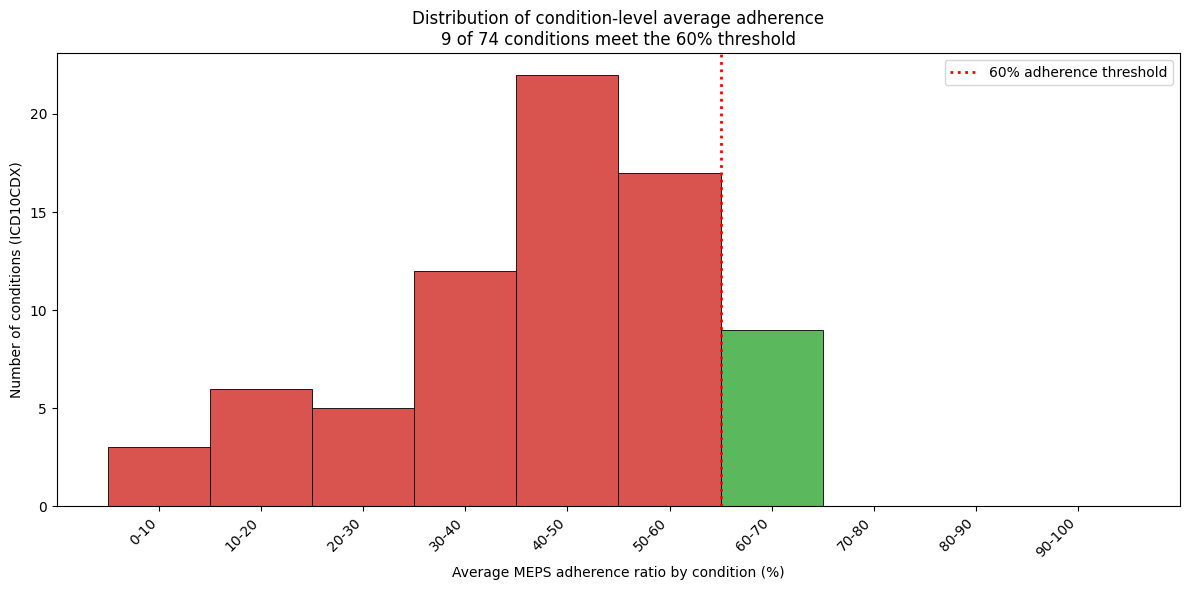

Adherent conditions (>=60%):


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio
23,F84,PERVASIVE DEVELOPMENTAL DISORDERS,66.514460
18,F20,SCHIZOPHRENIA,65.664224
9,E03,OTHER HYPOTHYROIDISM,63.652148
19,F31,BIPOLAR DISORDER,63.115170
71,R54,AGE-RELATED PHYSICAL DEBILITY,62.808219
34,I10,ESSENTIAL (PRIMARY) HYPERTENSION,62.309757
15,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,62.254202
36,I25,CHRONIC ISCHEMIC HEART DISEASE,61.361165
17,F19,OTHER PSYCHOACTIVE SUBSTANCE RELATED DISORDERS,60.563166


In [45]:
import matplotlib.pyplot as plt

by_condition = (
    grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

adherence_threshold = 60
bins = np.arange(0, 110, 10)

fig, ax = plt.subplots(figsize=(12, 6))
counts, edges, patches = ax.hist(
    by_condition["meps_adherence_ratio"],
    bins=bins,
    edgecolor="black",
    linewidth=0.6,
)

for patch, left, right in zip(patches, edges[:-1], edges[1:]):
    if right <= adherence_threshold:
        patch.set_facecolor("#d9534f")
    elif left >= adherence_threshold:
        patch.set_facecolor("#5cb85c")
    else:
        patch.set_facecolor("#f0ad4e")

ax.axvline(
    adherence_threshold,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"{adherence_threshold}% adherence threshold",
)

bin_labels = [f"{int(left)}-{int(right)}" for left, right in zip(edges[:-1], edges[1:])]
ax.set_xticks(edges[:-1] + 5)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")

n_adherent = (by_condition["meps_adherence_ratio"] >= adherence_threshold).sum()
n_total = len(by_condition)

ax.set_xlabel("Average MEPS adherence ratio by condition (%)")
ax.set_ylabel("Number of conditions (ICD10CDX)")
ax.set_title(
    f"Distribution of condition-level average adherence\n"
    f"{n_adherent} of {n_total} conditions meet the {adherence_threshold}% threshold"
)
ax.legend()
plt.tight_layout()
plt.show()

adherent_conditions = by_condition[
    by_condition["meps_adherence_ratio"] >= adherence_threshold
].sort_values("meps_adherence_ratio", ascending=False)

print(f"Adherent conditions (>={adherence_threshold}%):")
display(adherent_conditions)

Pearson correlation with meps_adherence_ratio
(ICD10CDX uses label encoding; interpret as a weak linear proxy only)



,pearson_r
ICD10CDX_code,-0.182687
TC1,0.134144
TC1S1,-0.021498



Eta-squared with meps_adherence_ratio
(better measure for categorical variables: share of variance explained)



,eta_squared
ICD10CDX,0.141394
TC1,0.118764
TC1S1,0.173514



Combined model: ICD10CDX + TC1 + TC1S1 together
  R-squared: 0.1923
  Adjusted R-squared: 0.1856


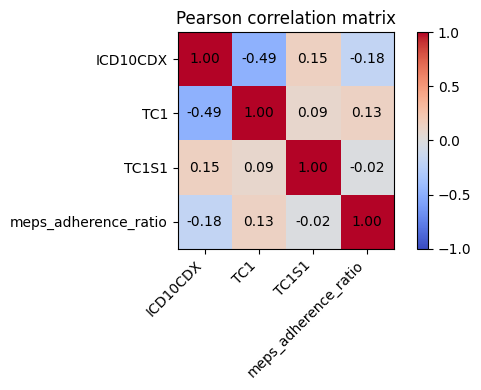

In [46]:
from sklearn.preprocessing import LabelEncoder

corr_df = grouped_merge_df.reset_index()[
    ["ICD10CDX", "TC1", "TC1S1", "meps_adherence_ratio"]
].dropna()

corr_df["ICD10CDX_code"] = LabelEncoder().fit_transform(corr_df["ICD10CDX"].astype(str))


def eta_squared(categorical, continuous):
    """Share of adherence variance explained by a categorical variable."""
    categories = categorical.astype(str)
    grand_mean = continuous.mean()
    ss_total = ((continuous - grand_mean) ** 2).sum()
    ss_between = sum(
        len(continuous[categories == cat]) * (continuous[categories == cat].mean() - grand_mean) ** 2
        for cat in categories.unique()
    )
    return ss_between / ss_total if ss_total > 0 else np.nan


pearson_corr = corr_df[
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"]
].corr(method="pearson")

pearson_with_adherence = pearson_corr["meps_adherence_ratio"].drop("meps_adherence_ratio")

eta_results = pd.Series(
    {
        "ICD10CDX": eta_squared(corr_df["ICD10CDX"], corr_df["meps_adherence_ratio"]),
        "TC1": eta_squared(corr_df["TC1"], corr_df["meps_adherence_ratio"]),
        "TC1S1": eta_squared(corr_df["TC1S1"], corr_df["meps_adherence_ratio"]),
    },
    name="eta_squared",
)

X = pd.get_dummies(
    corr_df[["ICD10CDX", "TC1", "TC1S1"]].astype(str),
    drop_first=True,
).astype(float)
y = corr_df["meps_adherence_ratio"].values
X_with_intercept = np.column_stack([np.ones(len(X)), X.values])
coeffs, _, _, _ = np.linalg.lstsq(X_with_intercept, y, rcond=None)
y_pred = X_with_intercept @ coeffs
ss_res = ((y - y_pred) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
combined_r2 = 1 - ss_res / ss_tot
n, p = len(y), X.shape[1]
adj_r2 = 1 - (1 - combined_r2) * (n - 1) / (n - p - 1)

print("Pearson correlation with meps_adherence_ratio")
print("(ICD10CDX uses label encoding; interpret as a weak linear proxy only)\n")
display(pearson_with_adherence.to_frame("pearson_r"))

print("\nEta-squared with meps_adherence_ratio")
print("(better measure for categorical variables: share of variance explained)\n")
display(eta_results.to_frame())

print("\nCombined model: ICD10CDX + TC1 + TC1S1 together")
print(f"  R-squared: {combined_r2:.4f}")
print(f"  Adjusted R-squared: {adj_r2:.4f}")

heatmap_data = pearson_corr.loc[
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"],
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"],
].rename(index={"ICD10CDX_code": "ICD10CDX"}, columns={"ICD10CDX_code": "ICD10CDX"})

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heatmap_data.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data.index)), heatmap_data.index)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(j, i, f"{heatmap_data.iloc[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

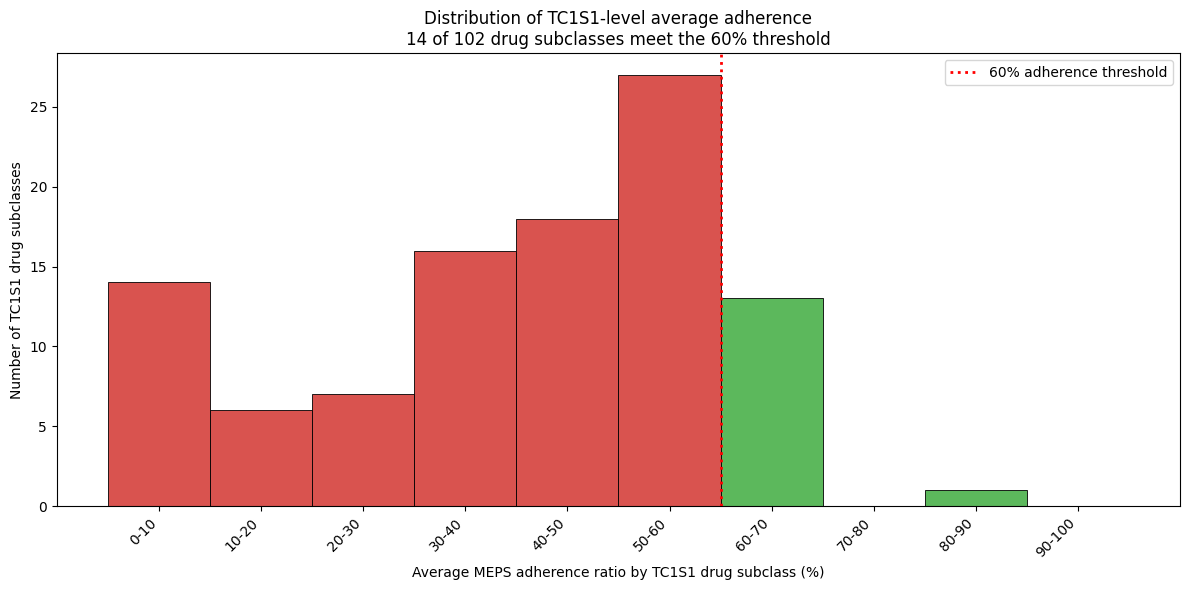

Adherent TC1S1 drug subclasses (>=60%):


,TC1,TC1S1,meps_adherence_ratio
27,40,51,82.191781
95,242,504,67.636986
14,20,23,66.682259
63,97,288,65.439030
30,40,55,65.332819
73,115,116,64.840183
19,40,42,64.673857
24,40,47,63.864588
62,97,103,63.534328
98,358,19,62.950928


In [47]:
by_tc1s1 = (
    grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

adherence_threshold = 60
bins = np.arange(0, 110, 10)

fig, ax = plt.subplots(figsize=(12, 6))
counts, edges, patches = ax.hist(
    by_tc1s1["meps_adherence_ratio"],
    bins=bins,
    edgecolor="black",
    linewidth=0.6,
)

for patch, left, right in zip(patches, edges[:-1], edges[1:]):
    if right <= adherence_threshold:
        patch.set_facecolor("#d9534f")
    elif left >= adherence_threshold:
        patch.set_facecolor("#5cb85c")
    else:
        patch.set_facecolor("#f0ad4e")

ax.axvline(
    adherence_threshold,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"{adherence_threshold}% adherence threshold",
)

bin_labels = [f"{int(left)}-{int(right)}" for left, right in zip(edges[:-1], edges[1:])]
ax.set_xticks(edges[:-1] + 5)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")

n_adherent = (by_tc1s1["meps_adherence_ratio"] >= adherence_threshold).sum()
n_total = len(by_tc1s1)

ax.set_xlabel("Average MEPS adherence ratio by TC1S1 drug subclass (%)")
ax.set_ylabel("Number of TC1S1 drug subclasses")
ax.set_title(
    f"Distribution of TC1S1-level average adherence\n"
    f"{n_adherent} of {n_total} drug subclasses meet the {adherence_threshold}% threshold"
)
ax.legend()
plt.tight_layout()
plt.show()

adherent_tc1s1 = by_tc1s1[
    by_tc1s1["meps_adherence_ratio"] >= adherence_threshold
].sort_values("meps_adherence_ratio", ascending=False)

print(f"Adherent TC1S1 drug subclasses (>={adherence_threshold}%):")
display(adherent_tc1s1)

In [48]:
low_adherence_threshold = 10

by_tc1s1 = (
    grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

by_condition = (
    grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

low_tc1s1 = (
    by_tc1s1[by_tc1s1["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

low_conditions = (
    by_condition[by_condition["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

print(f"TC1S1 drug subclasses with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_tc1s1)} of {len(by_tc1s1)}")
display(low_tc1s1)

print(f"\nICD10CDX conditions with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_conditions)} of {len(by_condition)}")
display(low_conditions)

TC1S1 drug subclasses with average adherence < 10%:
Count: 14 of 102


,TC1,TC1S1,meps_adherence_ratio
29,40,54,2.092154
71,113,266,2.356164
12,1,240,2.739726
2,1,2,2.773973
6,1,9,2.945205
3,1,4,3.522505
8,1,13,3.649840
7,1,11,4.132046
9,1,14,4.363267
79,122,124,5.886260



ICD10CDX conditions with average adherence < 10%:
Count: 3 of 74


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio
42,J32,CHRONIC SINUSITIS,6.559226
3,C44,OTHER AND UNSPECIFIED MALIGNANT NEOPLASM OF SKIN,7.880317
2,C43,MALIGNANT MELANOMA OF SKIN,8.258317


In [49]:
demo_df = pd.read_excel(MEPS_DIR / "h251.xlsx")
demo_df.head()

,DUID,PID,DUPERSID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID23,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR23,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE23,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS23,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE23,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION23,REFPRS31,REFPRS42,REFPRS53,REFPRS23,RESP31,RESP42,RESP53,RESP23,PROXY31,PROXY42,PROXY53,PROXY23,INTVLANG,INTVTYPE31,INTVTYPE42,INTVTYPE53,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM23,ENDRFY23,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP23,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND23,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE23X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY23X,SPOUID31,SPOUID42,SPOUID53,SPOUID23,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN23,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU23X,ACTDTY31,ACTDTY42,ACTDTY53,EVERSERVED,REFRL31X,REFRL42X,REFRL53X,REFRL23X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASATAK31,ASTHEP31,ASACUT31,ASMRCN31,ASPREV31,ASDALY31,ASPKFL31,ASEVFL31,ASWNFL31,ADHDADDX,ADHDAGED,COVIDEVER31,COVIDEVER53,LCEVER31,LCEVER53,COVSYMNOW31,COVSYMNOW53,COVREDABIL31,COVREDABIL53,COVID12MO31,COVID12MO53,COVMNTHX31,COVMNTHX53,COVYRDX31,COVYRDX53,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,IADLHP31,ADLHLP31,AIDHLP31,WLKLIM31,LFTDIF31,STPDIF31,WLKDIF31,MILDIF31,STNDIF31,BENDIF31,RCHDIF31,FNGRDF31,ACTLIM31,WRKLIM31,HSELIM31,SCHLIM31,UNABLE31,SOCLIM31,COGLIM31,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI23,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,GETTRB42,MOMPRO42,DADPRO42,UNHAP42,SCHLBH42,HAVFUN42,ADUPRO42,NERVAF42,SIBPRO42,KIDPRO42,SPRPRO42,SCHPRO42,HOMEBH42,CHILCR42,CHILWW42,CHRTCR42,CHRTWW42,CHAPPT42,CHLIST42,CHEXPL42,CHRESP42,CHPRTM42,CHHECR42,CHSPEC42_M18,CHEYRE42_M18,LSTETH53,PHYEXE53,OFTSMK53,COVAXEVR31,COVAXEVR42,COVAXEVR53,COVAXNEW31,COVAXNEW42,COVAXNEW53,SAQELIG,ADPROX42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADINSA42,ADINSB42,ADRISK42,ADOVER42,ADILCR42,ADILWW42,ADRTCR42,ADRTWW42,ADAPPT42,ADHECR42,ADINST42,ADEZUN42,ADTLHW42,ADFFRM42,ADFHLP42,ADEXPL42,ADLIST42,ADRESP42,ADPRTM42,ADSMOK42,ADNSMK42,ADSPCL42,ADSNSP42,VPCS42,VMCS42,VRFLAG42,ADCMPM42,ADCMPY42,ADLANG42,DDNWRK23,OTHDYS23,OTHNDD23,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,PROVSEX42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFRDCA42,DLAYDN42,AFRDDN42,DLAYPM42,AFRDPM42,EMPST31,EMPST42,EMPST53,RNDFLG31,MORJOB31,MORJOB42,MORJOB53,EVRWRK,HRWG31X,HRWG42X,HRWG53X,HRWGIM31,HRWGIM42,HRWGIM53,HRHOW31,HRHOW42,HRHOW53,DIFFWG31,DIFFWG42,DIFFWG53,NHRWGRND31,NHRWGRND42,NHRWGRND53,NHRWG31_M23,NHRWG42_M23,NHRWG53_M23,HOUR31,HOUR42,HOUR53,TEMPJB31,TEMPJB42,TEMPJB53,SSNLJB31,SSNLJB42,SSNLJB53,SELFCM31,SELFCM42,SELFCM53,DISVW31X,DISVW42X,DISVW53X,CHOIC31,CHOIC42,CHOIC53,INDCAT31,INDCAT31_17,INDCAT42_17,INDCAT53_17,NUMEMP31,NUMEMP42,NUMEMP53,MORE31,MORE42,MORE53,UNION31,UNION42,UNION53,NWK31,NWK42,NWK53,CHGJ3142,CHGJ4253,YCHJ3142,YCHJ4253,STJBMM31,STJBYY31,STJBMM42,STJBYY42,STJBMM53,STJBYY53,EVRETIRE,OCCCAT31,OCCCAT31_18,OCCCAT42_18,OCCCAT53_18,PAYVAC31,PAYVAC42,PAYVAC53,SICPAY31,SI

In [50]:
new_demo_df = demo_df[["DUPERSID","AGE23X","SEX","INSCOV23","POVCAT23","FAMINC23","PSTATS31","PSTATS53",
"PSTATS42","RACEV2X","BEGRFM31", "BEGRFY31", "BEGRFM42", "BEGRFY42", "BEGRFM53","BEGRFY53", "ENDRFM31", "ENDRFY31",
 "ENDRFM42", "ENDRFY42", "ENDRFM53",
"ENDRFY53","DLAYPM42","DLAYCA42"]]
new_demo_df.head()

,DUPERSID,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53,DLAYPM42,DLAYCA42
0,2790002101,58,2,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
1,2790002102,27,1,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
2,2790004101,49,2,1,5,87000,11,11,11,1,10,2022,5,2023,9,2023,5,2023,9,2023,12,2023,2,2
3,2790006101,75,2,2,4,38000,11,11,11,1,8,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2
4,2790006102,23,1,2,4,38000,11,11,11,1,8,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2


In [51]:
##1 - Any private (Person had any private insurance coverage [including
#TRICARE/CHAMPVA] at any time during 2023)
#2 - Public only (Person had only public insurance coverage [excluding
#TRICARE/CHAMPVA] during 2023)
#3 - Uninsured (Person was uninsured during all of 2023)

In [52]:
#POVCAT23 - Poverty level

#1 is Poor
#5 is high income

#PSTATS31 - if val is 31 - deseaced 

In [53]:

new_grouped_merge_df = grouped_merge_df.merge(new_demo_df, on="DUPERSID", how="left")
new_grouped_merge_df.head()


,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,total_days_supply,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53,DLAYPM42,DLAYCA42
0,2790002101,150,4.888,3.288,METFORMIN,70010006305,2020,358,99,E11,TYPE 2 DIABETES MELLITUS,150,365,41.095890,58,2,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
1,2790011101,270,10.000,10.000,PRAVASTATIN,93720298,2021,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,365,73.972603,71,1,1,5,79240,11,11,11,1,10,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2
2,2790011101,180,8.420,3.630,AMLODIPINE,68180072003,2022,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,71,1,1,5,79240,11,11,11,1,10,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2
3,2790011102,180,16.900,3.000,LOSARTAN POT,65862020299,2021,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,71,2,1,5,79240,11,11,11,1,10,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2
4,2790011102,30,5.620,2.330,ATORVASTATIN,43598083005,2023,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,365,8.219178,71,2,1,5,79240,11,11,11,1,10,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2


In [54]:
pstat_cols = ["PSTATS31", "PSTATS53", "PSTATS42"]
missing = [c for c in pstat_cols if c not in new_grouped_merge_df.columns]
if missing:
    raise KeyError(
        f"Missing {missing}. Re-run from the new_demo_df / merge cells "
        "(PSTATS columns are dropped later after reference-days are computed)."
    )

pstat_values = [31, 23, 24, 61]

pstat_df = new_grouped_merge_df.loc[
    new_grouped_merge_df["PSTATS31"].isin(pstat_values)
    | new_grouped_merge_df["PSTATS53"].isin(pstat_values)
    | new_grouped_merge_df["PSTATS42"].isin(pstat_values)
]

print(pstat_df.shape)
pstat_df.head()

(220, 37)


,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,total_days_supply,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53,DLAYPM42,DLAYCA42
1010,2791067101,180,8.200000,8.200000,CARVEDILOL,68382009505,2022,40,47,I48,ATRIAL FIBRILLATION AND FLUTTER,180,365,49.315068,-1,2,1,3,22800,11,-1,31,1,8,2022,2,2023,-1,-1,2,2023,3,2023,-1,-1,-1,-1
1334,2791395101,180,0.000000,0.000000,AMLODIPINE,68180072003,2018,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,-1,2,2,1,11380,11,-1,31,1,8,2022,5,2023,-1,-1,5,2023,7,2023,-1,-1,-1,-1
1335,2791395101,180,12.000000,12.000000,METOPROL SUC,55111046605,2018,40,47,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,-1,2,2,1,11380,11,-1,31,1,8,2022,5,2023,-1,-1,5,2023,7,2023,-1,-1,-1,-1
1336,2791395101,284,9160.866667,2577.953333,ANTINEOPLASTICS,-15,2017,20,-15,C50,MALIGNANT NEOPLASM OF BREAST,284,365,77.808219,-1,2,2,1,11380,11,-1,31,1,8,2022,5,2023,-1,-1,5,2023,7,2023,-1,-1,-1,-1
1651,2791637101,90,38.320000,5.000000,NIFEDIPINE,50742062001,2002,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,90,365,24.657534,-1,2,2,3,25770,31,-1,-1,1,8,2022,-1,-1,-1,-1,2,2023,-1,-1,-1,-1,-1,-1


In [55]:
pstat_values = [31,11, 12, 13, 14, 21, 22, 31, 32, 33, 34, 35, 41, 42, 43, 44, 51, 74, -1  ]
pstat_cols = ["PSTATS31", "PSTATS53", "PSTATS42"]
missing = [c for c in pstat_cols if c not in new_grouped_merge_df.columns]
if missing:
    raise KeyError(
        f"Missing {missing}. Re-run from the new_demo_df / merge cells "
        "(PSTATS columns are dropped later after reference-days are computed)."
    )

for val in pstat_values:
    mask = new_grouped_merge_df[pstat_cols].eq(val).any(axis=1)
    subset = new_grouped_merge_df.loc[mask, "total_valid_days"]
    print(f"PSTATS value {val} (rows where any PSTATS column == {val}): {len(subset)}")
    if len(subset) == 0:
        print("  No rows found.\n")
    else:
        display(subset.describe().to_frame(f"total_valid_days (PSTATS={val})"))
        print()

PSTATS value 31 (rows where any PSTATS column == 31): 220


,total_valid_days (PSTATS=31)
count,220.000000
mean,140.190909
std,100.146103
min,1.000000
25%,60.000000
50%,120.000000
75%,180.000000
max,365.000000



PSTATS value 11 (rows where any PSTATS column == 11): 21628


,total_valid_days (PSTATS=11)
count,21628.000000
mean,187.962040
std,123.210372
min,1.000000
25%,90.000000
50%,180.000000
75%,300.000000
max,365.000000



PSTATS value 12 (rows where any PSTATS column == 12): 14


...

,total_valid_days (PSTATS=44)
count,23.000000
mean,136.521739
std,108.416231
min,4.000000
25%,74.500000
50%,90.000000
75%,180.000000
max,365.000000



PSTATS value 51 (rows where any PSTATS column == 51): 6


,total_valid_days (PSTATS=51)
count,6.000000
mean,93.833333
std,136.441074
min,10.000000
25%,14.500000
50%,44.000000
75%,82.500000
max,365.000000



PSTATS value 74 (rows where any PSTATS column == 74): 0
  No rows found.

PSTATS value -1 (rows where any PSTATS column == -1): 177


,total_valid_days (PSTATS=-1)
count,177.000000
mean,113.887006
std,85.853461
min,1.000000
25%,30.000000
50%,90.000000
75%,180.000000
max,365.000000


In [56]:
from datetime import date
import calendar

# Year this notebook targets. Change if you clone this notebook to a new year.
YEAR = 2023

# PSTATS codes per h251doc.pdf Tables 7 and 8 (pp. C-14 to C-20).
# The MEPS PSTATS taxonomy is stable across years; the same codes apply
# to 2020-2023 (COVID year 2020 just has more -1 nonresponse).
PSTATS_LABELS = {
    11: "In RU, responded in person (full round)",
    12: "Active military duty (no survey)",
    13: "Moved from RU, known whereabouts",
    14: "Moved from RU, unknown whereabouts",
    21: "Hospitalized (rounds 4-5)",
    22: "Left institution, rejoined community (rounds 4-5)",
    23: "Left institution then died (rounds 4-5)",
    24: "Died in health-care institution (rounds 4-5)",
    31: "Deceased",
    32: "Institutionalized (health care)",
    33: "Institutionalized (non-health care)",
    34: "Moved outside US",
    35: "Moved to military facility on active duty",
    36: "Went to institution (type unknown)",
    41: "Joined RU after reference period began",
    42: "Joined RU, not full-time military",
    43: "Unknown disposition / moved to unknown location",
    44: "Moved to another RU in same PSU",
    51: "Newborn in reference period",
    62: "Institutionalized prior to reference period (R3/1 only)",
    71: "Non-Key student living away, grades 1-12",
    72: "Dropped as ineligible non-Key",
    73: "Non-Key moved without Key member",
    74: "Moved as FT military, no Key member (ineligible round)",
    81: "FT student living away, non-response",
    -1: "Not in this round",
}

# Full-round participants: use the whole reference-period window as-is.
FULL_ROUND_STATUSES = {11, 13, 14, 22, 41, 42, 44, 51, 71}
# Ended-early participants (excluding death, handled separately below):
# reference period cuts off partway through the round.
STOP_STATUSES = {32, 33, 34, 35, 36}
# No coverage in this round (Inapplicable reference period, ineligible,
# or out-of-scope for the whole round).
NO_COVERAGE_STATUSES = {0, 12, 21, 24, 43, 62, 63, 64, 72, 73, 74, 81}


def _month_start(year, month):
    if pd.isna(month) or pd.isna(year) or month <= 0 or year <= 0:
        return None
    return date(int(year), int(month), 1)


def _month_end(year, month):
    if pd.isna(month) or pd.isna(year) or month <= 0 or year <= 0:
        return None
    return date(int(year), int(month), calendar.monthrange(int(year), int(month))[1])


def _round_detail(row, round_suffix):
    ps = int(row[f"PSTATS{round_suffix}"])
    return {
        "round": round_suffix,
        "pstats": ps,
        "pstats_label": PSTATS_LABELS.get(ps, f"Code {ps}"),
        "ref_start": _month_start(row[f"BEGRFY{round_suffix}"], row[f"BEGRFM{round_suffix}"]),
        "ref_end": _month_end(row[f"ENDRFY{round_suffix}"], row[f"ENDRFM{round_suffix}"]),
    }


def compute_reference_coverage(row, year=YEAR):
    """Return eligible days, coverage start/end, and notes from PSTATS + BEGRF/ENDRF.

    PSTATS == -1 means the person was not in that round (skip; no days added or removed).
    """
    year_start = date(year, 1, 1)
    year_end = date(year, 12, 31)

    active_rounds = [
        sfx for sfx in [31, 42, 53] if int(row[f"PSTATS{sfx}"]) != -1
    ]
    if not active_rounds:
        return 0, None, None, "not_in_any_round"

    if all(int(row[f"PSTATS{sfx}"]) == 11 for sfx in [31, 42, 53]):
        return 365, year_start, year_end, "full_year_all_rounds_11"

    coverage_start = None
    coverage_end = None
    notes = []

    for round_suffix in [31, 42, 53]:
        ps = int(row[f"PSTATS{round_suffix}"])
        beg = _month_start(row[f"BEGRFY{round_suffix}"], row[f"BEGRFM{round_suffix}"])
        end = _month_end(row[f"ENDRFY{round_suffix}"], row[f"ENDRFM{round_suffix}"])

        if ps == -1:
            notes.append(f"R{round_suffix}:not_in_round")
            continue
        if ps in NO_COVERAGE_STATUSES:
            notes.append(f"R{round_suffix}:no_coverage({ps})")
            continue

        if coverage_start is None:
            coverage_start = max(beg, year_start) if beg else year_start

        if ps in FULL_ROUND_STATUSES:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:active({ps})")
        elif ps == 31:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:death")
            break
        elif ps in STOP_STATUSES:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:stop({ps})")
            break
        else:
            # Unknown PSTATS code — leave a marker instead of silently including.
            notes.append(f"R{round_suffix}:UNCLASSIFIED({ps})")

    if coverage_start is None or coverage_end is None or coverage_end < coverage_start:
        return 0, None, None, "no_coverage"

    days = (coverage_end - coverage_start).days + 1
    return days, coverage_start, coverage_end, ";".join(notes)


person_demo = new_demo_df.drop_duplicates("DUPERSID").copy()
coverage_parts = person_demo.apply(compute_reference_coverage, axis=1, result_type="expand")
person_demo["total_days_supply"] = coverage_parts[0]
person_demo["ref_start_2023"] = coverage_parts[1]
person_demo["ref_end_2023"] = coverage_parts[2]
person_demo["coverage_notes"] = coverage_parts[3]

person_demo["in_round_31"] = person_demo["PSTATS31"] != -1
person_demo["in_round_42"] = person_demo["PSTATS42"] != -1
person_demo["in_round_53"] = person_demo["PSTATS53"] != -1

# Flag: person missed the last round (R5/3). Their denominator is truncated
# at the R4/2 interview date, but any fill captured at R4/2 with a long
# RXDAYSUP will keep adding days past that endpoint. Result: MPR can be
# biased upward (often pinned to 100% by the np.minimum cap below).
person_demo["r53_nonresponse"] = person_demo["PSTATS53"] == -1

person_demo["participation_type"] = np.select(
    [
        person_demo["coverage_notes"].eq("full_year_all_rounds_11"),
        person_demo["coverage_notes"].eq("not_in_any_round"),
        person_demo["coverage_notes"].str.contains("death", na=False),
        person_demo["coverage_notes"].str.contains("stop", na=False),
        person_demo["coverage_notes"].str.contains("no_coverage", na=False),
        person_demo["total_days_supply"].eq(0),
    ],
    [
        "full_year",
        "not_in_any_round",
        "ended_early_death",
        "ended_early_left_ru",
        "partial_no_survey",
        "no_coverage",
    ],
    default="partial_year",
)

reference_days_df = person_demo[
    [
        "DUPERSID",
        "in_round_31",
        "in_round_42",
        "in_round_53",
        "ref_start_2023",
        "ref_end_2023",
        "total_days_supply",
        "participation_type",
        "coverage_notes",
        "r53_nonresponse",
    ]
]

ROUND_DETAIL_COLS = [
    "PSTATS31", "PSTATS42", "PSTATS53",
    "BEGRFM31", "BEGRFY31", "ENDRFM31", "ENDRFY31",
    "BEGRFM42", "BEGRFY42", "ENDRFM42", "ENDRFY42",
    "BEGRFM53", "BEGRFY53", "ENDRFM53", "ENDRFY53",
]
new_demo_df = new_demo_df.drop(columns=ROUND_DETAIL_COLS, errors="ignore")

print("Participation type counts:")
display(reference_days_df["participation_type"].value_counts().to_frame("persons"))

# Diagnostic: how many persons might have MPR biased upward by R5/3 nonresponse?
n_r53 = int(reference_days_df["r53_nonresponse"].sum())
print(f"\nR5/3 nonresponders flagged (PSTATS53 == -1): {n_r53} persons")
print("  Their denominator cuts off at the R4/2 interview date, but their")
print("  numerator (sum RXDAYSUP) can include fill days that extend past it.")
print("  Downstream: their MPR is at risk of being biased HIGH (often 100%).")

# Diagnostic: were any PSTATS codes in the data left UNCLASSIFIED after
# the extended classification above?
unclassified = person_demo[person_demo["coverage_notes"].str.contains("UNCLASSIFIED", na=False)]
if len(unclassified):
    print(f"\nWARNING: {len(unclassified)} persons still have unclassified PSTATS values.")
    print("  Inspect person_demo[person_demo['coverage_notes'].str.contains('UNCLASSIFIED')].")
else:
    print("\nAll PSTATS codes in this year's data were classified. ✓")

print("\nSample: full-year vs partial vs deceased")
display(
    reference_days_df[
        reference_days_df["participation_type"].isin(
            ["full_year", "ended_early_death", "partial_year", "partial_no_survey"]
        )
    ].head(10)
)


Participation type counts:


,persons
participation_type,
full_year,17680
partial_year,979
ended_early_death,165
ended_early_left_ru,63
partial_no_survey,32



R5/3 nonresponders flagged (PSTATS53 == -1): 137 persons
  Their denominator cuts off at the R4/2 interview date, but their
  numerator (sum RXDAYSUP) can include fill days that extend past it.
  Downstream: their MPR is at risk of being biased HIGH (often 100%).

All PSTATS codes in this year's data were classified. ✓

Sample: full-year vs partial vs deceased


,DUPERSID,in_round_31,in_round_42,in_round_53,ref_start_2023,ref_end_2023,total_days_supply,participation_type,coverage_notes,r53_nonresponse
0,2790002101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
1,2790002102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
2,2790004101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
3,2790006101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
4,2790006102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
5,2790007101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
6,2790011101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
7,2790011102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
8,2790012101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
9,2790012102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False


In [57]:
new_grouped_merge_df = new_grouped_merge_df.drop(
    columns=[
        "total_days_supply",
        "ref_start_2023",
        "ref_end_2023",
        "participation_type",
        "coverage_notes",
        "r53_nonresponse",
    ],
    errors="ignore",
)

new_grouped_merge_df = new_grouped_merge_df.merge(
    reference_days_df[
        [
            "DUPERSID",
            "total_days_supply",
            "ref_start_2023",
            "ref_end_2023",
            "participation_type",
            "coverage_notes",
            "r53_nonresponse",
        ]
    ],
    on="DUPERSID",
    how="left",
)

new_grouped_merge_df["total_valid_days"] = np.minimum(
    new_grouped_merge_df["total_valid_days"],
    new_grouped_merge_df["total_days_supply"],
)

new_grouped_merge_df["meps_adherence_ratio"] = np.where(
    new_grouped_merge_df["total_days_supply"].eq(0),
    np.nan,
    new_grouped_merge_df["total_valid_days"] / new_grouped_merge_df["total_days_supply"] * 100,
)

ROUND_DETAIL_COLS = [
    "PSTATS31", "PSTATS42", "PSTATS53",
    "BEGRFM31", "BEGRFY31", "ENDRFM31", "ENDRFY31",
    "BEGRFM42", "BEGRFY42", "ENDRFM42", "ENDRFY42",
    "BEGRFM53", "BEGRFY53", "ENDRFM53", "ENDRFY53",
]
new_grouped_merge_df = new_grouped_merge_df.drop(columns=ROUND_DETAIL_COLS, errors="ignore")

print("total_days_supply (PSTATS-based) summary:")
display(new_grouped_merge_df["total_days_supply"].describe().to_frame())

print("\nmeps_adherence_ratio after update:")
display(new_grouped_merge_df["meps_adherence_ratio"].describe().to_frame())

# Diagnostic: how much does R5/3-nonresponse bias inflate mean MPR?
overall = new_grouped_merge_df["meps_adherence_ratio"]
excl_r53 = new_grouped_merge_df.loc[
    ~new_grouped_merge_df["r53_nonresponse"].fillna(False), "meps_adherence_ratio"
]
n_r53_pairs = int(new_grouped_merge_df["r53_nonresponse"].fillna(False).sum())
print(f"\nR5/3-nonresponse impact on person-drug pairs: {n_r53_pairs} pairs affected")
print(f"  mean MPR overall:                    {overall.mean():.2f}%")
print(f"  mean MPR excluding R5/3 nonresponders: {excl_r53.mean():.2f}%")
print("  (If the excluded mean is materially lower, the flagged rows are")
print("   inflating the ratio via numerator-bleed past the truncated denominator.)")

print("\nCompare old flat 365 vs new PSTATS-based denominator:")
compare = reference_days_df.groupby("participation_type").agg(
    persons=("DUPERSID", "count"),
    mean_days=("total_days_supply", "mean"),
    min_days=("total_days_supply", "min"),
    max_days=("total_days_supply", "max"),
)
display(compare)


total_days_supply (PSTATS-based) summary:


,total_days_supply
count,21685.000000
mean,363.118884
std,18.862955
min,0.000000
25%,365.000000
50%,365.000000
75%,365.000000
max,365.000000



meps_adherence_ratio after update:


,meps_adherence_ratio
count,21681.000000
mean,51.704852
std,33.782716
min,0.273973
25%,24.657534
50%,49.315068
75%,82.191781
max,100.000000



R5/3-nonresponse impact on person-drug pairs: 124 pairs affected
  mean MPR overall:                    51.70%
  mean MPR excluding R5/3 nonresponders: 51.65%
  (If the excluded mean is materially lower, the flagged rows are
   inflating the ratio via numerator-bleed past the truncated denominator.)

Compare old flat 365 vs new PSTATS-based denominator:


,persons,mean_days,min_days,max_days
participation_type,,,,
ended_early_death,165,210.387879,31,365
ended_early_left_ru,63,184.984127,31,365
full_year,17680,365.000000,365,365
partial_no_survey,32,89.375000,0,334
partial_year,979,306.204290,31,365


In [58]:
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse
0,2790002101,150,4.888,3.288,METFORMIN,70010006305,2020,358,99,E11,TYPE 2 DIABETES MELLITUS,150,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
1,2790011101,270,10.000,10.000,PRAVASTATIN,93720298,2021,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
2,2790011101,180,8.420,3.630,AMLODIPINE,68180072003,2022,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
3,2790011102,180,16.900,3.000,LOSARTAN POT,65862020299,2021,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
4,2790011102,30,5.620,2.330,ATORVASTATIN,43598083005,2023,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,8.219178,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False


In [59]:
rxname_df = pd.read_csv(MEPS_DIR / "unique_rxname_chronic_labeled_revised.csv")
rxname_df.head()

,RXNAME,drug_condition_type,is_chronic
0,-15,non_chronic,0
1,12HOUR NASAL,flare_up,0
2,5-AMINOSALICYLATES,chronic,1
3,600+D3,non_chronic,0
4,ABILIFY MAIN,chronic,1


In [60]:
new_grouped_merge_df = pd.merge(new_grouped_merge_df, rxname_df, on="RXNAME", how="left")
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse,drug_condition_type,is_chronic
0,2790002101,150,4.888,3.288,METFORMIN,70010006305,2020,358,99,E11,TYPE 2 DIABETES MELLITUS,150,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
1,2790011101,270,10.000,10.000,PRAVASTATIN,93720298,2021,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
2,2790011101,180,8.420,3.630,AMLODIPINE,68180072003,2022,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
3,2790011102,180,16.900,3.000,LOSARTAN POT,65862020299,2021,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
4,2790011102,30,5.620,2.330,ATORVASTATIN,43598083005,2023,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,8.219178,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1


In [61]:
#new_grouped_merge_df.drop(columns = ["drug_condition_type_y","is_chronic_y"],inplace = True)

In [62]:
new_grouped_merge_df["is_chronic"].value_counts()

is_chronic
1    16441
0     5244
Name: count, dtype: int64

In [63]:
new_grouped_merge_df = new_grouped_merge_df[new_grouped_merge_df["is_chronic"]==1]
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse,drug_condition_type,is_chronic
0,2790002101,150,4.888,3.288,METFORMIN,70010006305,2020,358,99,E11,TYPE 2 DIABETES MELLITUS,150,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
1,2790011101,270,10.000,10.000,PRAVASTATIN,93720298,2021,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
2,2790011101,180,8.420,3.630,AMLODIPINE,68180072003,2022,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
3,2790011102,180,16.900,3.000,LOSARTAN POT,65862020299,2021,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
4,2790011102,30,5.620,2.330,ATORVASTATIN,43598083005,2023,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,8.219178,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1


In [64]:
by_drug_class = (
    new_grouped_merge_df.groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
    .sort_values("meps_adherence_ratio", ascending=False)
)

top_10_highest = by_drug_class.head(10)
top_10_lowest = by_drug_class.tail(10).sort_values("meps_adherence_ratio", ascending=True)

print("Top 10 highest mean adherence:")
display(top_10_highest)

print("Top 10 lowest mean adherence:")
display(top_10_lowest)

Top 10 highest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
35,87,88,100.000000
17,40,51,82.191781
60,242,504,70.484153
64,358,194,67.491064
4,20,23,66.947982
1,1,5,66.743941
2,1,7,65.753425
43,97,288,65.520140
19,40,55,65.475593
9,40,42,64.891868


Top 10 lowest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
37,87,95,8.219178
47,105,460,8.219178
40,97,98,26.016860
53,122,130,27.007376
36,87,91,29.589041
56,133,247,31.084640
31,57,516,31.680365
39,87,355,33.844749
29,57,312,35.433790
28,57,80,37.010627


In [65]:
low_adherence_threshold = 10

by_tc1s1 = (
    new_grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

by_condition = (
    new_grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

low_tc1s1 = (
    by_tc1s1[by_tc1s1["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

low_conditions = (
    by_condition[by_condition["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

print(f"TC1S1 drug subclasses with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_tc1s1)} of {len(by_tc1s1)}")
display(low_tc1s1)

print(f"\nICD10CDX conditions with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_conditions)} of {len(by_condition)}")
display(low_conditions)

TC1S1 drug subclasses with average adherence < 10%:
Count: 2 of 66


,TC1,TC1S1,meps_adherence_ratio
37,87,95,8.219178
47,105,460,8.219178



ICD10CDX conditions with average adherence < 10%:
Count: 1 of 71


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio
2,C44,OTHER AND UNSPECIFIED MALIGNANT NEOPLASM OF SKIN,8.219178


In [66]:
top_20_least_adherent = (
    new_grouped_merge_df
    .dropna(subset=["meps_adherence_ratio"])
    .groupby(["ICD10CDX", "ICD10CDX_LABEL", "RXNAME"], as_index=False)
    .agg(
        meps_adherence_ratio=("meps_adherence_ratio", "mean"),
        patient_drug_pairs=("DUPERSID", "count"),
    )
    .nsmallest(20, "meps_adherence_ratio")
    .sort_values("meps_adherence_ratio", ascending=True)
    .reset_index(drop=True)
)

print("Top 20 least adherent conditions with drug name:")
display(top_20_least_adherent)

Top 20 least adherent conditions with drug name:


,ICD10CDX,ICD10CDX_LABEL,RXNAME,meps_adherence_ratio,patient_drug_pairs
0,F99,"MENTAL DISORDER, NOT OTHERWISE SPECIFIED",CARDIOVASCULAR AGENTS,0.547945,1
1,K57,DIVERTICULAR DISEASE OF INTESTINE,DICYCLOMINE,0.547945,1
2,E11,TYPE 2 DIABETES MELLITUS,POT CHLORIDE,1.095890,1
3,H35,OTHER RETINAL DISORDERS,IMMUNOLOGIC AGENTS,1.095890,1
4,E11,TYPE 2 DIABETES MELLITUS,POTASSIUM CL ER,1.232877,2
5,M51,"THORACIC, THORACOLUM, AND LUMBOSACRAL INTVRT D...",XTAMPZA ER,1.917808,1
6,N40,BENIGN PROSTATIC HYPERPLASIA,XTAMPZA ER,1.917808,1
7,I49,OTHER CARDIAC ARRHYTHMIAS,NITROGLYCERN,2.054795,2
8,I50,HEART FAILURE,NITROGLYCERN,2.191781,1
9,I48,ATRIAL FIBRILLATION AND FLUTTER,NITROGLYCERN,2.191781,1


In [67]:
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse,drug_condition_type,is_chronic
0,2790002101,150,4.888,3.288,METFORMIN,70010006305,2020,358,99,E11,TYPE 2 DIABETES MELLITUS,150,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
1,2790011101,270,10.000,10.000,PRAVASTATIN,93720298,2021,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
2,2790011101,180,8.420,3.630,AMLODIPINE,68180072003,2022,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
3,2790011102,180,16.900,3.000,LOSARTAN POT,65862020299,2021,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
4,2790011102,30,5.620,2.330,ATORVASTATIN,43598083005,2023,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,8.219178,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1


In [68]:
new_grouped_merge_df.columns.tolist()

['DUPERSID',
 'RXDAYSUP',
 'RXXP23X',
 'RXSF23X',
 'RXNAME',
 'RXNDC',
 'RXBEGYRX',
 'TC1',
 'TC1S1',
 'ICD10CDX',
 'ICD10CDX_LABEL',
 'total_valid_days',
 'meps_adherence_ratio',
 'AGE23X',
 'SEX',
 'INSCOV23',
 'POVCAT23',
 'FAMINC23',
 'RACEV2X',
 'DLAYPM42',
 'DLAYCA42',
 'total_days_supply',
 'ref_start_2023',
 'ref_end_2023',
 'participation_type',
 'coverage_notes',
 'r53_nonresponse',
 'drug_condition_type',
 'is_chronic']

In [69]:
delay_df = demo_df[["DUPERSID", "DLAYPM42", "DLAYCA42"]].drop_duplicates("DUPERSID")
new_grouped_merge_df = new_grouped_merge_df.drop(
    columns=["DLAYPM42", "DLAYCA42"], errors="ignore"
).merge(delay_df, on="DUPERSID", how="left")

model_df = new_grouped_merge_df[['DUPERSID','RXNAME','ICD10CDX','ICD10CDX_LABEL','AGE23X','SEX','INSCOV23',
 'POVCAT23','FAMINC23','RACEV2X','DLAYPM42','DLAYCA42','meps_adherence_ratio']]

In [70]:
model_df.head()

,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,meps_adherence_ratio
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,2,2,41.095890
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,2,2,73.972603
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,2,2,49.315068
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,2,2,49.315068
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2,2,8.219178


In [71]:
model_df['is_adherent'] = np.where(model_df['meps_adherence_ratio'] >= 60, 1, 0)

neg_mask = model_df.select_dtypes(include="number").lt(0).any(axis=1)
n_dropped = int(neg_mask.sum())
model_df = model_df.loc[~neg_mask].copy()
print(f"Dropped RXNDC earlier; dropped {n_dropped} rows with negatives; remaining {len(model_df)}")

model_df.head()

Dropped RXNDC earlier; dropped 148 rows with negatives; remaining 16293


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,2,2,41.095890,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,2,2,73.972603,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,2,2,49.315068,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,2,2,49.315068,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2,2,8.219178,0


In [72]:
# Drop RXNDC (if still present) and remove any row with a negative numeric value
model_df = model_df.drop(columns=["RXNDC"], errors="ignore")

feature_cols = [
    c for c in model_df.columns
    if c not in {"DUPERSID", "RXNAME", "ICD10CDX", "ICD10CDX_LABEL"}
]
for c in feature_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

print("Negative counts BEFORE drop:")
print(model_df[feature_cols].lt(0).sum().sort_values(ascending=False))

neg_mask = model_df[feature_cols].lt(0).any(axis=1)
n_before = len(model_df)
model_df = model_df.loc[~neg_mask].copy()

print(f"\nDropped {int(neg_mask.sum())} rows with negatives ({n_before} -> {len(model_df)})")
print("Negative counts AFTER drop:")
print(model_df[feature_cols].lt(0).sum().sort_values(ascending=False))
model_df.head()


Negative counts BEFORE drop:
AGE23X                  0
SEX                     0
INSCOV23                0
POVCAT23                0
FAMINC23                0
RACEV2X                 0
DLAYPM42                0
DLAYCA42                0
meps_adherence_ratio    0
is_adherent             0
dtype: int64

Dropped 0 rows with negatives (16293 -> 16293)
Negative counts AFTER drop:
AGE23X                  0
SEX                     0
INSCOV23                0
POVCAT23                0
FAMINC23                0
RACEV2X                 0
DLAYPM42                0
DLAYCA42                0
meps_adherence_ratio    0
is_adherent             0
dtype: int64


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,2,2,41.095890,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,2,2,73.972603,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,2,2,49.315068,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,2,2,49.315068,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2,2,8.219178,0


In [73]:
model_df.describe()

,DUPERSID,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent
count,1.629300e+04,16293.000000,16293.000000,16293.000000,16293.000000,16293.000000,16293.000000,16293.00000,16293.000000,16291.000000,16293.000000
mean,2.805908e+09,61.450132,1.549561,1.493279,3.679801,84262.989627,1.599583,1.93623,1.930829,57.720908,0.461916
std,1.032857e+07,16.765414,0.497553,0.532201,1.424560,81030.330242,1.989502,0.24435,0.253752,31.962981,0.498563
min,2.790002e+09,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.00000,1.000000,0.273973,0.000000
25%,2.795543e+09,53.000000,1.000000,1.000000,3.000000,26256.000000,1.000000,2.00000,2.000000,24.657534,0.000000
50%,2.810836e+09,65.000000,2.000000,1.000000,4.000000,60000.000000,1.000000,2.00000,2.000000,49.315068,0.000000
75%,2.815294e+09,74.000000,2.000000,2.000000,5.000000,116300.000000,1.000000,2.00000,2.000000,94.657534,1.000000
max,2.819788e+09,85.000000,2.000000,3.000000,5.000000,740270.000000,12.000000,2.00000,2.000000,100.000000,1.000000


In [74]:
model_df['INSCOV23'].unique()

array([1, 2, 3])

In [75]:
model_df['INSCOV23'] = model_df['INSCOV23'].replace({2:1,3:0},inplace=True)
model_df.head()

/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_2385/3890125338.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  model_df['INSCOV23'] = model_df['INSCOV23'].replace({2:1,3:0},inplace=True)


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,2,2,41.095890,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,2,2,73.972603,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,2,2,49.315068,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,2,2,49.315068,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2,2,8.219178,0


In [76]:
model_df['MALE'] = np.where(model_df['SEX']==1, 1, 0)
model_df['FEMALE'] = np.where(model_df['SEX']==2, 1, 0)
model_df.drop(columns = ['SEX'],inplace = True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent,MALE,FEMALE
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,1,5,130700,2,2,2,41.095890,0,0,1
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,5,79240,1,2,2,73.972603,1,1,0
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,5,79240,1,2,2,49.315068,0,1,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,5,79240,1,2,2,49.315068,0,0,1
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,5,79240,1,2,2,8.219178,0,0,1


In [77]:
model_df['RACEV2X'].unique()


model_df['WHITE'] = np.where(model_df['RACEV2X']==1, 1, 0)
model_df['BLACK'] = np.where(model_df['RACEV2X']==2, 1, 0)
model_df['AMER_INDIAN'] = np.where(model_df['RACEV2X']==3, 1, 0)
model_df['ASIAN_INDIAN'] = np.where(model_df['RACEV2X']==4, 1, 0)
model_df['CHINESE'] = np.where(model_df['RACEV2X']==5, 1, 0)
model_df['FILIPINO'] = np.where(model_df['RACEV2X']==6, 1, 0)


# 1 WHITE - NO OTHER RACE REPORTED 14,118 250,268,262
# 2 BLACK - NO OTHER RACE REPORTED 2,666 44,558,431
# 3 AMER INDIAN/ALASKA NATIVE-NO OTHER RACE 163 2,838,974
# 4 ASIAN INDIAN - NO OTHER RACE REPORTED 380 7,055,957
# 5 CHINESE - NO OTHER RACE REPORTED 272 5,400,356
# 6 FILIPINO - NO OTHER RACE REPORTED 174 3,110,110
# 10 OTH ASIAN/NATV HAWAIIAN/PACFC ISL-NO OTH 422 7,436,055
# 12 MULTIPLE RACES REPORTED 
model_df.drop(columns = ['RACEV2X'],inplace = True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,INSCOV23,POVCAT23,FAMINC23,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,1,5,130700,2,2,41.095890,0,0,1,0,1,0,0,0,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,5,79240,2,2,73.972603,1,1,0,1,0,0,0,0,0
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,5,79240,2,2,49.315068,0,1,0,1,0,0,0,0,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,5,79240,2,2,49.315068,0,0,1,1,0,0,0,0,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,5,79240,2,2,8.219178,0,0,1,1,0,0,0,0,0


In [78]:
# DLAYPM42 / DLAYCA42 may already be dropped — pull them back from demo_df if needed
if "DLAYPM42" not in model_df.columns or "DLAYCA42" not in model_df.columns:
    delay_df = demo_df[["DUPERSID", "DLAYPM42", "DLAYCA42"]].drop_duplicates("DUPERSID")
    model_df = model_df.drop(columns=["DLAYPM42", "DLAYCA42"], errors="ignore").merge(
        delay_df, on="DUPERSID", how="left"
    )

# 1=YES delayed for cost, 2=NO
model_df["PMED_DELAY_COST"] = np.where(model_df["DLAYPM42"] == 1, 1, 0)
model_df["NO_PMED_DELAY_COST"] = np.where(model_df["DLAYPM42"] == 2, 1, 0)

model_df["CARE_DELAY_COST"] = np.where(model_df["DLAYCA42"] == 1, 1, 0)
model_df["NO_CARE_DELAY_COST"] = np.where(model_df["DLAYCA42"] == 2, 1, 0)

model_df.drop(columns=["DLAYPM42", "DLAYCA42"], inplace=True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,INSCOV23,POVCAT23,FAMINC23,meps_adherence_ratio,is_adherent,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,1,5,130700,41.095890,0,0,1,0,1,0,0,0,0,0,1,0,1
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,5,79240,73.972603,1,1,0,1,0,0,0,0,0,0,1,0,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,5,79240,49.315068,0,1,0,1,0,0,0,0,0,0,1,0,1
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,5,79240,49.315068,0,0,1,1,0,0,0,0,0,0,1,0,1
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,5,79240,8.219178,0,0,1,1,0,0,0,0,0,0,1,0,1


In [79]:
# POVCAT23 may already be dropped — pull it back from demo_df if needed
if "POVCAT23" not in model_df.columns:
    pov_df = demo_df[["DUPERSID", "POVCAT23"]].drop_duplicates("DUPERSID")
    model_df = model_df.merge(pov_df, on="DUPERSID", how="left")

# 1=Poor ... 5=High income
model_df["POV_POOR"] = np.where(model_df["POVCAT23"] == 1, 1, 0)
model_df["POV_NEAR_POOR"] = np.where(model_df["POVCAT23"] == 2, 1, 0)
model_df["POV_LOW"] = np.where(model_df["POVCAT23"] == 3, 1, 0)
model_df["POV_MIDDLE"] = np.where(model_df["POVCAT23"] == 4, 1, 0)
model_df["POV_HIGH"] = np.where(model_df["POVCAT23"] == 5, 1, 0)

model_df.drop(columns=["POVCAT23"], inplace=True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,INSCOV23,FAMINC23,meps_adherence_ratio,is_adherent,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,1,130700,41.095890,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,79240,73.972603,1,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,79240,49.315068,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,79240,49.315068,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,79240,8.219178,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1


In [80]:
model_df["ICD10CDX_LABEL"].nunique()

71

In [81]:
model_df["RXNAME"].value_counts().tolist()

[1195,
 767,
 766,
 691,
 571,
 534,
 446,
 352,
 339,
 330,
 308,
 305,
 246,
 234,
 218,
 202,
 197,
 180,
 178,
 178,
 172,
 169,
 167,
 164,
 158,
 151,
 128,
 127,
 120,
 118,
 117,
 117,
 117,
 114,
 104,
 101,
 92,
 91,
 90,
 89,
 86,
 86,
 86,
 85,
 80,
 79,
 79,
 78,
 75,
 73,
 71,
 70,
 69,
 67,
 65,
 65,
 63,
 63,
 63,
 63,
 63,
 60,
 60,
 60,
 59,
 57,
 57,
 55,
 54,
 54,
 53,
 52,
 50,
 49,
 49,
 48,
 48,
 47,
 47,
 42,
 42,
 41,
 41,
 41,
 39,
 39,
 39,
 38,
 37,
 36,
 36,
 36,
 36,
 35,
 35,
 34,
 33,
 32,
 32,
 31,
 30,
 29,
 29,
 29,
 29,
 28,
 28,
 27,
 27,
 27,
 27,
 26,
 26,
 25,
 25,
 25,
 25,
 25,
 25,
 25,
 25,
 24,
 24,
 23,
 23,
 23,
 22,
 22,
 22,
 22,
 22,
 22,
 21,
 21,
 21,
 21,
 21,
 20,
 20,
 20,
 19,
 19,
 19,
 19,
 19,
 18,
 18,
 18,
 18,
 18,
 18,
 17,
 17,
 17,
 17,
 17,
 17,
 16,
 16,
 16,
 16,
 16,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 14,
 14,
 14,
 13,
 13,
 13,
 13,
 13,
 13,
 12,
 12,
 12,
 12,
 12,
 11,
 11,
 11,
 11,
 11,
 11,
 10,
 10,
 10,
 9,

In [82]:
rx_counts = model_df["RXNAME"].value_counts(dropna=False)
n_once = int((rx_counts >9).sum())

print(f"unique RXNAME: {rx_counts.shape[0]}")
print(f"RXNAME appearing exactly once: {n_once}")
print(f"share of unique names: {100 * n_once / rx_counts.shape[0]:.1f}%")
print(f"share of rows: {100 * n_once / len(model_df):.1f}%")
rx_counts[rx_counts >9 ]


unique RXNAME: 406
RXNAME appearing exactly once: 192
share of unique names: 47.3%
share of rows: 1.2%


RXNAME
ATORVASTATIN                            1195
METFORMIN                                767
LISINOPRIL                               766
AMLODIPINE                               691
LOSARTAN POT                             571
                                        ... 
OXCARBAZEPIN                              11
OLANZAPINE                                11
DOPAMINERGIC ANTIPARKINSONISM AGENTS      10
CONCERTA                                  10
ASPIRIN TAB DELAYED RELEASE 81 MG         10
Name: count, Length: 192, dtype: int64

In [83]:
rx_counts = model_df["RXNAME"].value_counts()
keep_names = rx_counts[rx_counts >= 10].index

n_before = len(model_df)
n_names_before = model_df["RXNAME"].nunique()
model_df = model_df[model_df["RXNAME"].isin(keep_names)].copy()

print(f"rows: {n_before} -> {len(model_df)}")
print(f"unique RXNAME: {n_names_before} -> {model_df['RXNAME'].nunique()}")
print(f"dropped medications appearing < 10 times: {n_names_before - model_df['RXNAME'].nunique()}")
model_df.head()


rows: 16293 -> 15748
unique RXNAME: 406 -> 192
dropped medications appearing < 10 times: 214


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,INSCOV23,FAMINC23,meps_adherence_ratio,is_adherent,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,1,130700,41.095890,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,79240,73.972603,1,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,79240,49.315068,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,79240,49.315068,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,79240,8.219178,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1


In [84]:
# One-hot encode RXNAME: each medication becomes its own 0/1 column
rx_dummies = pd.get_dummies(model_df["RXNAME"], prefix="RX").astype(int)
model_df = pd.concat([model_df.drop(columns=["RXNAME"]), rx_dummies], axis=1)

print(f"added {rx_dummies.shape[1]} RXNAME dummy columns")
print(f"model_df shape: {model_df.shape}")
model_df.head()


added 192 RXNAME dummy columns
model_df shape: (15748, 217)


,DUPERSID,ICD10CDX,ICD10CDX_LABEL,AGE23X,INSCOV23,FAMINC23,meps_adherence_ratio,is_adherent,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH,RX_5-AMINOSALICYLATES,RX_ADDERALL XR,RX_ADVAIR DISKU,RX_ADVAIR HFA,RX_ALENDRONATE,RX_ALLOPURINOL,RX_AMIODARONE,RX_AMITRIPTYLIN,RX_AMLOD/BENAZP,RX_AMLODIPINE,RX_AMPHET/DEXTR,RX_ANASTROZOLE,RX_ANGIOTENSIN II INHIBITORS WITH THIAZIDES,RX_ANTIANGINAL AGENTS,RX_ANTICONVULSANTS,RX_ANTIDIABETIC AGENTS,RX_ANTIHYPERLIPIDEMIC AGENTS,RX_ANTIHYPERTENSIVE COMBINATIONS,RX_ANTINEOPLASTIC HORMONES,RX_ANTINEOPLASTICS,RX_ARIPIPRAZOLE,RX_ARMOUR THYRO,RX_ASPIRIN LOW,RX_ASPIRIN TAB DELAYED RELEASE 81 MG,RX_ATENOLOL,RX_ATOMOXETINE,RX_ATORVASTATIN,RX_ATYPICAL ANTIPSYCHOTICS,RX_BACLOFEN,RX_BASAGLAR,RX_BENAZEPRIL,RX_BISOPROL FUM,RX_BISPHOSPHONATES,RX_BREO ELLIPTA,RX_BRIMONIDINE,RX_BUDES/FORMOT,RX_BUDESONIDE,RX_BUPROPION,RX_BUPROPN HCL,RX_BUSPIRONE,RX_CARBAMAZEPIN,RX_CARDIOVASCULAR AGENTS,RX_CARVEDILOL,RX_CHLORTHALID,RX_CITALOPRAM,RX_CLONIDINE,RX_CLOPIDOGREL,RX_CNS STIMULANTS,RX_COAGULATION MODIFIERS,RX_CONCERTA,RX_DESVENLAFAX,RX_DEXMETHYLPHE,RX_DICYCLOMINE,RX_DILTIAZEM,RX_DIVALPROEX,RX_DONEPEZIL,RX_DOPAMINERGIC ANTIPARKINSONISM AGENTS,RX_DORZOL/TIMOL,RX_DORZOLAMIDE,RX_DOXAZOSIN,RX_DOXEPIN HCL,RX_DULOXETINE,RX_ELIQUIS,RX_ENALAPRIL,RX_ENTRESTO,RX_ESCITALOPRAM,RX_ESTRADIOL,RX_EZETIMIBE,RX_FARXIGA,RX_FENOFIBRATE,RX_FIBRIC ACID DERIVATIVES,RX_FINASTERIDE,RX_FLECAINIDE,RX_FLOVENT HFA,RX_FLUOXETINE,RX_FLUTIC/SALME,RX_FLUTICASONE,RX_FREESTYLE,RX_FUNCTIONAL BOWEL DISORDER AGENTS,RX_FUROSEMIDE,RX_GABAPENTIN,RX_GLARGIN YFGN,RX_GLIMEPIRIDE,RX_GLIPIZIDE,RX_GLIPIZIDE ER,RX_GROUP I ANTIARRHYTHMICS,RX_GROUP III ANTIARRHYTHMICS,RX_GROUP V ANTIARRHYTHMICS,RX_HUMALOG,RX_HUMALOG KWIK,RX_HUMIRA,RX_HUMIRA PEN,RX_HYDRALAZINE,RX_HYDROCHLOROT,RX_HYDROXYCHLOR,RX_IMMUNOLOGIC AGENTS,RX_INHALED CORTICOSTEROIDS,RX_INSULIN,RX_INSULIN ASPA,RX_INSULIN LISP,RX_IRBESARTAN,RX_ISOSORB MONO,RX_JANUVIA,RX_JARDIANCE,RX_LABETALOL,RX_LAMOTRIGINE,RX_LANTUS,RX_LANTUS SOLOS,RX_LATANOPROST,RX_LEVEMIR,RX_LEVETIRACETA,RX_LEVOTHYROXIN,RX_LINZESS,RX_LIOTHYRONINE,RX_LISINOP/HCTZ,RX_LISINOPRIL,RX_LITHIUM CARB,RX_LOSARTAN POT,RX_LOSARTAN/HCT,RX_LOVASTATIN,RX_MEMANTINE,RX_METFORMIN,RX_METHOTREXATE,RX_METHYLPHENID,RX_METOPROL SUC,RX_METOPROL TAR,RX_MIRTAZAPINE,RX_MONTELUKAST,RX_MORPHINE SUL,RX_MOUNJARO,RX_MYRBETRIQ,RX_NEBIVOLOL,RX_NIFEDIPINE,RX_NITROGLYCERN,RX_NORTRIPTYLIN,RX_NOVOLIN,RX_NOVOLOG,RX_NP THYROID,RX_OLANZAPINE,RX_OLMESA MEDOX,RX_OPHTHALMIC GLAUCOMA AGENTS,RX_OXCARBAZEPIN,RX_OXYBUTYNIN,RX_OZEMPIC,RX_PAROXETINE,RX_PIOGLITAZONE,RX_POT CHLORIDE,RX_PRAMIPEXOLE,RX_PRAVASTATIN,RX_PREGABALIN,RX_PROGESTERONE,RX_PROPRANOLOL,RX_PSYCHOTHERAPEUTIC AGENTS,RX_QUETIAPINE,RX_RAMIPRIL,RX_REPATHA,RX_RISPERIDONE,RX_ROPINIROLE,RX_ROSUVASTATIN,RX_RYBELSUS,RX_SERTRALINE,RX_SGLT-2 INHIBITORS,RX_SIMVASTATIN,RX_SPIRIVA,RX_SPIRONOLACT,RX_SYMBICORT,RX_SYNTHROID,RX_TAMSULOSIN,RX_TELMISARTAN,RX_TERAZOSIN,RX_TESTOST CYP,RX_TESTOSTERONE,RX_TIMOLOL MAL,RX_TOPIRAMATE,RX_TORSEMIDE,RX_TOUJEO SOLO,RX_TRADJENTA,RX_TRAZODONE,RX_TRELEGY,RX_TRESIBA FLEX,RX_TRIAMT/HCTZ,RX_TRULICITY,RX_URINARY ANTISPASMODICS,RX_VALSARTAN,RX_VASCEPA,RX_VENLAFAXINE,RX_VERAPAMIL,RX_VICTOZA,RX_VYVANSE,RX_WARFARIN,RX_WIXELA INHUB,RX_XARELTO
0,2790002101,E11,TYPE 2 DIABETES MELLITUS,58,1,130700,41.095890,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2790011101,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,79240,73.972603,1,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [85]:
model_df["ICD10CDX"].nunique()

71

In [86]:
model_df["ICD10CDX"].value_counts()

ICD10CDX
I10    3917
E11    2664
E78    2147
F32     987
F41     861
       ... 
H54       1
F19       1
M17       1
R26       1
C44       1
Name: count, Length: 71, dtype: int64

In [88]:
icd_counts = model_df["ICD10CDX"].value_counts(dropna=False)
n_once = int((icd_counts >9).sum())

print(f"unique ICD10CDX: {icd_counts.shape[0]}")
print(f"ICD10CDX appearing exactly once: {n_once}")
print(f"share of unique codes: {100 * n_once / icd_counts.shape[0]:.1f}%")
print(f"share of rows: {100 * n_once / len(model_df):.1f}%")
icd_counts[icd_counts >9]


unique ICD10CDX: 71
ICD10CDX appearing exactly once: 54
share of unique codes: 76.1%
share of rows: 0.3%


ICD10CDX
I10    3917
E11    2664
E78    2147
F32     987
F41     861
J45     598
E03     538
F90     446
I25     319
G47     317
I48     243
J30     213
H40     172
N40     158
Z79     136
F31     130
M06     122
M19     115
M10     107
G62     104
M54      94
I49      90
F99      74
I50      74
G25      72
J44      67
R32      66
G40      63
E05      59
C50      56
M81      52
C61      49
M85      41
I51      39
E34      38
J32      37
F03      35
F20      35
C73      32
K58      31
E29      29
F39      28
K59      27
M51      27
K21      24
G20      22
E28      21
C95      21
J43      19
F84      16
I20      13
N19      12
K50      12
M53      10
Name: count, dtype: int64

In [89]:
# One-hot encode ICD10CDX: each condition code becomes its own 0/1 column
icd_dummies = pd.get_dummies(model_df["ICD10CDX"], prefix="ICD").astype(int)
model_df = pd.concat([model_df.drop(columns=["ICD10CDX"]), icd_dummies], axis=1)

print(f"added {icd_dummies.shape[1]} ICD10CDX dummy columns")
print(f"model_df shape: {model_df.shape}")
model_df.head()


added 71 ICD10CDX dummy columns
model_df shape: (15748, 287)


,DUPERSID,ICD10CDX_LABEL,AGE23X,INSCOV23,FAMINC23,meps_adherence_ratio,is_adherent,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH,RX_5-AMINOSALICYLATES,RX_ADDERALL XR,RX_ADVAIR DISKU,RX_ADVAIR HFA,RX_ALENDRONATE,RX_ALLOPURINOL,RX_AMIODARONE,RX_AMITRIPTYLIN,RX_AMLOD/BENAZP,RX_AMLODIPINE,RX_AMPHET/DEXTR,RX_ANASTROZOLE,RX_ANGIOTENSIN II INHIBITORS WITH THIAZIDES,RX_ANTIANGINAL AGENTS,RX_ANTICONVULSANTS,RX_ANTIDIABETIC AGENTS,RX_ANTIHYPERLIPIDEMIC AGENTS,RX_ANTIHYPERTENSIVE COMBINATIONS,RX_ANTINEOPLASTIC HORMONES,RX_ANTINEOPLASTICS,RX_ARIPIPRAZOLE,RX_ARMOUR THYRO,RX_ASPIRIN LOW,RX_ASPIRIN TAB DELAYED RELEASE 81 MG,RX_ATENOLOL,RX_ATOMOXETINE,RX_ATORVASTATIN,RX_ATYPICAL ANTIPSYCHOTICS,RX_BACLOFEN,RX_BASAGLAR,RX_BENAZEPRIL,RX_BISOPROL FUM,RX_BISPHOSPHONATES,RX_BREO ELLIPTA,RX_BRIMONIDINE,RX_BUDES/FORMOT,RX_BUDESONIDE,RX_BUPROPION,RX_BUPROPN HCL,RX_BUSPIRONE,RX_CARBAMAZEPIN,RX_CARDIOVASCULAR AGENTS,RX_CARVEDILOL,RX_CHLORTHALID,RX_CITALOPRAM,RX_CLONIDINE,RX_CLOPIDOGREL,RX_CNS STIMULANTS,RX_COAGULATION MODIFIERS,RX_CONCERTA,RX_DESVENLAFAX,RX_DEXMETHYLPHE,RX_DICYCLOMINE,RX_DILTIAZEM,RX_DIVALPROEX,RX_DONEPEZIL,RX_DOPAMINERGIC ANTIPARKINSONISM AGENTS,RX_DORZOL/TIMOL,RX_DORZOLAMIDE,RX_DOXAZOSIN,RX_DOXEPIN HCL,RX_DULOXETINE,RX_ELIQUIS,RX_ENALAPRIL,RX_ENTRESTO,RX_ESCITALOPRAM,RX_ESTRADIOL,RX_EZETIMIBE,RX_FARXIGA,RX_FENOFIBRATE,RX_FIBRIC ACID DERIVATIVES,RX_FINASTERIDE,RX_FLECAINIDE,RX_FLOVENT HFA,RX_FLUOXETINE,RX_FLUTIC/SALME,RX_FLUTICASONE,RX_FREESTYLE,RX_FUNCTIONAL BOWEL DISORDER AGENTS,RX_FUROSEMIDE,RX_GABAPENTIN,RX_GLARGIN YFGN,RX_GLIMEPIRIDE,RX_GLIPIZIDE,RX_GLIPIZIDE ER,RX_GROUP I ANTIARRHYTHMICS,RX_GROUP III ANTIARRHYTHMICS,RX_GROUP V ANTIARRHYTHMICS,RX_HUMALOG,RX_HUMALOG KWIK,RX_HUMIRA,RX_HUMIRA PEN,RX_HYDRALAZINE,RX_HYDROCHLOROT,RX_HYDROXYCHLOR,RX_IMMUNOLOGIC AGENTS,RX_INHALED CORTICOSTEROIDS,RX_INSULIN,RX_INSULIN ASPA,RX_INSULIN LISP,RX_IRBESARTAN,RX_ISOSORB MONO,RX_JANUVIA,RX_JARDIANCE,RX_LABETALOL,RX_LAMOTRIGINE,RX_LANTUS,RX_LANTUS SOLOS,RX_LATANOPROST,RX_LEVEMIR,RX_LEVETIRACETA,RX_LEVOTHYROXIN,RX_LINZESS,RX_LIOTHYRONINE,RX_LISINOP/HCTZ,RX_LISINOPRIL,RX_LITHIUM CARB,RX_LOSARTAN POT,RX_LOSARTAN/HCT,RX_LOVASTATIN,RX_MEMANTINE,RX_METFORMIN,RX_METHOTREXATE,RX_METHYLPHENID,RX_METOPROL SUC,RX_METOPROL TAR,RX_MIRTAZAPINE,RX_MONTELUKAST,RX_MORPHINE SUL,RX_MOUNJARO,RX_MYRBETRIQ,RX_NEBIVOLOL,RX_NIFEDIPINE,RX_NITROGLYCERN,RX_NORTRIPTYLIN,RX_NOVOLIN,RX_NOVOLOG,RX_NP THYROID,RX_OLANZAPINE,RX_OLMESA MEDOX,RX_OPHTHALMIC GLAUCOMA AGENTS,RX_OXCARBAZEPIN,RX_OXYBUTYNIN,RX_OZEMPIC,RX_PAROXETINE,RX_PIOGLITAZONE,RX_POT CHLORIDE,RX_PRAMIPEXOLE,RX_PRAVASTATIN,RX_PREGABALIN,RX_PROGESTERONE,RX_PROPRANOLOL,RX_PSYCHOTHERAPEUTIC AGENTS,RX_QUETIAPINE,RX_RAMIPRIL,RX_REPATHA,RX_RISPERIDONE,RX_ROPINIROLE,RX_ROSUVASTATIN,RX_RYBELSUS,RX_SERTRALINE,RX_SGLT-2 INHIBITORS,RX_SIMVASTATIN,RX_SPIRIVA,RX_SPIRONOLACT,RX_SYMBICORT,RX_SYNTHROID,RX_TAMSULOSIN,RX_TELMISARTAN,RX_TERAZOSIN,RX_TESTOST CYP,RX_TESTOSTERONE,RX_TIMOLOL MAL,RX_TOPIRAMATE,RX_TORSEMIDE,RX_TOUJEO SOLO,RX_TRADJENTA,RX_TRAZODONE,RX_TRELEGY,RX_TRESIBA FLEX,RX_TRIAMT/HCTZ,RX_TRULICITY,RX_URINARY ANTISPASMODICS,RX_VALSARTAN,RX_VASCEPA,RX_VENLAFAXINE,RX_VERAPAMIL,RX_VICTOZA,RX_VYVANSE,RX_WARFARIN,RX_WIXELA INHUB,RX_XARELTO,ICD_C18,ICD_C34,ICD_C44,ICD_C50,ICD_C61,ICD_C67,ICD_C73,ICD_C95,ICD_E03,ICD_E05,ICD_E11,ICD_E28,ICD_E29,ICD_E34,ICD_E78,ICD_F03,ICD_F19,ICD_F20,ICD_F31,ICD_F32,ICD_F39,ICD_F41,ICD_F84,ICD_F90,ICD_F99,ICD_G20,ICD_G25,ICD_G40,ICD_G47,ICD_G62,ICD_H35,ICD_H40,ICD_H54,ICD_I10,ICD_I20,ICD_I25,ICD_I48,ICD_I49,ICD_I50,ICD_I51,ICD_J30,ICD_J32,ICD_J42,ICD_J43,ICD_J44,ICD_J45,ICD_K21,ICD_K50,ICD_K57,ICD_K58,ICD_K59,ICD_K76,ICD_M06,ICD_M10,ICD_M17,ICD_M19,ICD_M35,ICD_M48,ICD_M50,ICD_M51,ICD_M53,ICD_M54,ICD_M81,ICD_M85,ICD_N18,ICD_N19,ICD_N40,ICD_R26,ICD_R32,ICD_U09,ICD_Z79
0,2790002101,TYPE 2 DIABETES MELLITUS,58,1,130700,41.095890,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,

In [90]:
# Rebuild pair-level model_df WITHOUT dropping rare RXNAMEs, then collapse to 1 row per patient.
# Drug/condition dummies use max (any mention -> 1). Adherence = mean across drugs; adherent if mean >= 60.

# --- 1) rebuild pair-level frame from new_grouped_merge_df (includes all drugs) ---
delay_df = demo_df[["DUPERSID", "DLAYPM42", "DLAYCA42"]].drop_duplicates("DUPERSID")
base = new_grouped_merge_df.drop(columns=["DLAYPM42", "DLAYCA42"], errors="ignore").merge(
    delay_df, on="DUPERSID", how="left"
)

model_df = base[
    [
        "DUPERSID", "RXNAME", "ICD10CDX", "ICD10CDX_LABEL",
        "AGE23X", "SEX", "INSCOV23", "POVCAT23", "FAMINC23", "RACEV2X",
        "DLAYPM42", "DLAYCA42", "meps_adherence_ratio",
    ]
].copy()

# drop negatives (same rule as before)
feature_cols = [
    c for c in model_df.columns
    if c not in {"DUPERSID", "RXNAME", "ICD10CDX", "ICD10CDX_LABEL"}
]
for c in feature_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")
model_df = model_df.loc[~model_df[feature_cols].lt(0).any(axis=1)].copy()

# encodings (same as earlier notebook cells)
model_df["INSCOV23"] = model_df["INSCOV23"].replace({2: 1, 3: 0})

model_df["MALE"] = np.where(model_df["SEX"] == 1, 1, 0)
model_df["FEMALE"] = np.where(model_df["SEX"] == 2, 1, 0)
model_df = model_df.drop(columns=["SEX"])

model_df["WHITE"] = np.where(model_df["RACEV2X"] == 1, 1, 0)
model_df["BLACK"] = np.where(model_df["RACEV2X"] == 2, 1, 0)
model_df["AMER_INDIAN"] = np.where(model_df["RACEV2X"] == 3, 1, 0)
model_df["ASIAN_INDIAN"] = np.where(model_df["RACEV2X"] == 4, 1, 0)
model_df["CHINESE"] = np.where(model_df["RACEV2X"] == 5, 1, 0)
model_df["FILIPINO"] = np.where(model_df["RACEV2X"] == 6, 1, 0)
model_df = model_df.drop(columns=["RACEV2X"])

model_df["PMED_DELAY_COST"] = np.where(model_df["DLAYPM42"] == 1, 1, 0)
model_df["NO_PMED_DELAY_COST"] = np.where(model_df["DLAYPM42"] == 2, 1, 0)
model_df["CARE_DELAY_COST"] = np.where(model_df["DLAYCA42"] == 1, 1, 0)
model_df["NO_CARE_DELAY_COST"] = np.where(model_df["DLAYCA42"] == 2, 1, 0)
model_df = model_df.drop(columns=["DLAYPM42", "DLAYCA42"])

model_df["POV_POOR"] = np.where(model_df["POVCAT23"] == 1, 1, 0)
model_df["POV_NEAR_POOR"] = np.where(model_df["POVCAT23"] == 2, 1, 0)
model_df["POV_LOW"] = np.where(model_df["POVCAT23"] == 3, 1, 0)
model_df["POV_MIDDLE"] = np.where(model_df["POVCAT23"] == 4, 1, 0)
model_df["POV_HIGH"] = np.where(model_df["POVCAT23"] == 5, 1, 0)
model_df = model_df.drop(columns=["POVCAT23"])

# drop label; keep ICD10CDX for one-hot
model_df = model_df.drop(columns=["ICD10CDX_LABEL"])

print(f"pair-level rows (all drugs kept): {len(model_df):,}")
print(f"unique patients: {model_df['DUPERSID'].nunique():,}")
print(f"unique RXNAME: {model_df['RXNAME'].nunique():,}")
print(f"unique ICD10CDX: {model_df['ICD10CDX'].nunique():,}")
model_df.head()


pair-level rows (all drugs kept): 16,293
unique patients: 5,889
unique RXNAME: 406
unique ICD10CDX: 71


,DUPERSID,RXNAME,ICD10CDX,AGE23X,INSCOV23,FAMINC23,meps_adherence_ratio,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH
0,2790002101,METFORMIN,E11,58,1,130700,41.095890,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1
1,2790011101,PRAVASTATIN,E78,71,1,79240,73.972603,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
2,2790011101,AMLODIPINE,I10,71,1,79240,49.315068,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
3,2790011102,LOSARTAN POT,I10,71,1,79240,49.315068,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
4,2790011102,ATORVASTATIN,E78,71,1,79240,8.219178,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1


In [91]:
# --- 2) one-hot drugs + conditions (0/1), then 1 row per patient ---
rx_dummies = pd.get_dummies(model_df["RXNAME"], prefix="RX").astype(int)
icd_dummies = pd.get_dummies(model_df["ICD10CDX"], prefix="ICD").astype(int)

pair_df = pd.concat(
    [model_df.drop(columns=["RXNAME", "ICD10CDX"]), rx_dummies, icd_dummies],
    axis=1,
)

rx_cols = [c for c in pair_df.columns if c.startswith("RX_")]
icd_cols = [c for c in pair_df.columns if c.startswith("ICD_")]
person_cols = [
    c for c in pair_df.columns
    if c not in {"DUPERSID", "meps_adherence_ratio"} and c not in rx_cols and c not in icd_cols
]

agg = {c: "max" for c in person_cols + rx_cols + icd_cols}
agg["meps_adherence_ratio"] = "mean"

model_df = pair_df.groupby("DUPERSID", as_index=False).agg(agg)
model_df["is_adherent"] = np.where(model_df["meps_adherence_ratio"] >= 60, 1, 0)

print(f"patient-level rows: {len(model_df):,} (should equal unique DUPERSID)")
print(f"RX dummy cols: {len(rx_cols)} | ICD dummy cols: {len(icd_cols)}")
print(f"is_adherent value counts:\n{model_df['is_adherent'].value_counts()}")
model_df.head()


patient-level rows: 5,889 (should equal unique DUPERSID)
RX dummy cols: 406 | ICD dummy cols: 71
is_adherent value counts:
is_adherent
0    3376
1    2513
Name: count, dtype: int64


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_2385/2752842802.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df = pair_df.groupby("DUPERSID", as_index=False).agg(agg)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_2385/2752842802.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df["is_adherent"] = np.where(model_df["meps_adherence_ratio"] >= 60, 1, 0)


,DUPERSID,AGE23X,INSCOV23,FAMINC23,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH,RX_5-AMINOSALICYLATES,RX_ABILIFY MAIN,RX_ACE INHIBITORS WITH THIAZIDES,RX_ADDERALL XR,RX_ADMELOG,RX_ADVAIR DISKU,RX_ADVAIR HFA,RX_AIRDUO DGHLR,RX_ALENDRONATE,RX_ALLOPURINOL,RX_ALPHA-ADRENORECEPTOR ANTAGONISTS,RX_ALPHAGAN P,RX_AMIODARONE,RX_AMITRIPTYLIN,RX_AMLOD/BENAZP,RX_AMLODIPINE,RX_AMLODIPINE BESYLATE,RX_AMLODIPINE BESYLATE TAB,RX_AMPHET/DEXTR,RX_AMPHETAMINE ER TAB,RX_ANASTROZOLE,RX_ANGIOTENSIN CONVERTING ENZYME (ACE) INHIBITORS,RX_ANGIOTENSIN II INHIBITORS,RX_ANGIOTENSIN II INHIBITORS WITH THIAZIDES,RX_ANTIANGINAL AGENTS,RX_ANTICHOLINERGICS/ANTISPASMODICS,RX_ANTICONVULSANTS,RX_ANTIDIABETIC AGENTS,RX_ANTIHYPERLIPIDEMIC AGENTS,RX_ANTIHYPERTENSIVE COMBINATIONS,RX_ANTINEOPLASTIC HORMONES,RX_ANTINEOPLASTICS,RX_APIXABAN,RX_ARIPIPRAZOLE,RX_ARMOUR THYRO,RX_ARNUITY ELPT,RX_ASPIRIN 81,RX_ASPIRIN CHEW TAB 81 MG,RX_ASPIRIN LOW,RX_ASPIRIN TAB DELAYED RELEASE 81 MG,RX_ATENOLOL,RX_ATOMOXETINE,RX_ATORVASTATIN,RX_ATORVASTATIN CA,RX_ATORVASTATIN CALCIUM TAB,RX_ATORVASTATIN TAB,RX_ATYPICAL ANTIPSYCHOTICS,RX_BACLOFEN,RX_BARBITURATE ANTICONVULSANTS,RX_BASAGLAR,RX_BASAGLAR INJ 100UNIT,RX_BENAZEPRIL,RX_BENAZEPRIL TAB,RX_BENZODIAZEPINE ANTICONVULSANTS,"RX_BETA BLOCKERS, NON-CARDIOSELECTIVE",RX_BETAHISTINE,RX_BISOPROL FUM,RX_BISOPROLOL FUMARATE,RX_BISPHOSPHONATES,RX_BREO ELLIPTA,RX_BRILINTA,RX_BRIMONIDINE,RX_BRIMONIDINE TARTRATE,RX_BUDES/FORMOT,RX_BUDESONIDE,RX_BUMETANIDE,RX_BUPROPION,RX_BUPROPION HCL SR,RX_BUPROPION HCL XL,RX_BUPROPION XL,RX_BUPROPN HCL,RX_BUPROPN HCL TAB,RX_BUSPIRONE,RX_BUSPIRONE TAB,RX_BYSTOLIC,RX_C-T3 18MCG E4M,RX_CALC ACETATE,RX_CALCITRIOL,RX_CARB/LEVO,RX_CARBAMAZEPIN,RX_CARBONIC ANHYDRASE INHIBITORS,RX_CARDIOVASCULAR AGENTS,RX_CARTIA XT,RX_CARVEDILOL,RX_CEQUA,RX_CGRP INHIBITORS,RX_CHLORTHALID,RX_CHOLINERGIC AGONISTS,RX_CHOLINESTERASE INHIBITORS,RX_CITALOPRAM,RX_CLONIDINE,RX_CLOPIDOGREL,RX_CMP-PROGESTERONE SR,RX_CNS STIMULANTS,RX_COAGULATION MODIFIERS,RX_CONCERTA,RX_CONTOUR,RX_CREON,RX_CRESTOR,RX_CROMOLYN SOD,RX_CYCLOSPORINE,RX_DEPO-TESTOST,RX_DESVENLAFAX,RX_DEXMETHYLPH,RX_DEXMETHYLPHE,RX_DEXTROAMP-AMPHETAMIN,RX_DEXTROAMP-AMPHETAMINE,RX_DEXTROAMP-AMPHETAMINE ER,RX_DEXTROAMPHET-AMPHET ER,RX_DICYCLOMINE,RX_DICYCLOMINE CAP,RX_DICYCLOMINE TAB,RX_DILT-XR,RX_DILTIAZEM,RX_DILTIAZEM ER,RX_DILTIAZEM EXTENDED RELEASE,RX_DIOVAN,RX_DIURETICS,RX_DIVALPROEX,RX_DONEPEZIL,RX_DONEPEZIL HYDROCHLORIDE,RX_DOPAMINERGIC ANTIPARKINSONISM AGENTS,RX_DORZOL/TIMOL,RX_DORZOLAMIDE,RX_DOXAZOSIN,RX_DOXAZOSIN TAB,RX_DOXEPIN,RX_DOXEPIN HCL,RX_DULAGLUTIDE,RX_DULOXETINE,RX_DULOXETINE HCL,RX_DUTASTERIDE,RX_EASY COMFORT,RX_EFFEXOR XR,RX_ELIQUIS,RX_ELIQUIS TAB,RX_EMTR/TENOFOV,RX_ENALAPRIL,RX_ENTRESTO,RX_ESCITALOPRAM,RX_ESCITALOPRAM OXALATE TAB,RX_ESTRAD VAL,RX_ESTRADIOL,RX_ESTROGEL,RX_ESTROGENS,RX_EUTHYROX,RX_EZETIMIBE,RX_FARXIGA,RX_FASTCLIX,RX_FENOFIBRATE,RX_FIASP FLEX,RX_FIBRIC ACID DERIVATIVES,RX_FINASTERIDE,RX_FLECAINIDE,RX_FLOVENT DISK,RX_FLOVENT HFA,RX_FLUOXETINE,RX_FLUOXETINE HCL,RX_FLUTIC/SALME,RX_FLUTIC/VILAN,RX_FLUTICAS HFA,RX_FLUTICASONE,RX_FOCALIN XR,RX_FREESTY LIBR,RX_FREESTYLE,RX_FUNCTIONAL BOWEL DISORDER AGENTS,RX_FUROSEMIDE,RX_GABAPENTIIN,RX_GABAPENTIN,RX_GABAPENTIN CAP,RX_GABAPENTIN/KETOPROFEN/LIDOCAINE PERME 6%-10%-2% -,RX_GLARGIN YFGN,RX_GLIMEPIRIDE,RX_GLIPIZID ER,RX_GLIPIZIDE,RX_GLIPIZIDE ER,RX_GLIPIZIDE XL,RX_GLP-1 RECEPTOR AGONISTS,RX_GROUP I ANTIARRHYTHMICS,RX_GROUP II ANTIARRHYTHMICS,RX_GROUP III ANTIARRHYTHMICS,RX_GROUP V ANTIARRHYTHMICS,RX_GUANFACINE,RX_HMG-COA REDUCTASE INHIBITORS (STATINS),RX_HORIZANT,RX_HUMALOG,RX_HUMALOG JR,RX_HUMALOG KWIK,RX_HUMIRA,RX_HUMIRA PEN,RX_HUMULIN,RX_HYDRALAZINE,RX_HYDROCHLOROT,RX_HYDROCHLOROTHIAZIDE,RX_HYDROXYCHLOR,RX_HYDROXYCHLOROQUINE SULFATE,RX_ICOSAPENT,RX_IMMUNOLOGIC AGENTS,RX_IMVEXXY STRT,RX_INHALED CORTICOSTEROIDS,RX_INS DEGL FLX,RX_INSULIN,RX_INSULIN ASPA,RX_INSULIN DETEMIR,RX_INS

In [92]:
# Counts + examples: patients with >1 drug and/or >1 condition
rx_cols = [c for c in model_df.columns if c.startswith("RX_")]
icd_cols = [c for c in model_df.columns if c.startswith("ICD_")]

model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)

n_multi_drug = int((model_df["n_drugs"] > 1).sum())
n_multi_cond = int((model_df["n_conditions"] > 1).sum())
n_both = int(((model_df["n_drugs"] > 1) & (model_df["n_conditions"] > 1)).sum())

print(f"patients total: {len(model_df):,}")
print(f"patients with >1 drug: {n_multi_drug:,}")
print(f"patients with >1 condition: {n_multi_cond:,}")
print(f"patients with >1 drug AND >1 condition: {n_both:,}")

print("\nn_drugs distribution:")
display(model_df["n_drugs"].value_counts().sort_index().head(15))
print("\nn_conditions distribution:")
display(model_df["n_conditions"].value_counts().sort_index().head(15))

# Example patients
example_cols = ["DUPERSID", "n_drugs", "n_conditions", "meps_adherence_ratio", "is_adherent"]

print("\n--- examples: >1 drug ---")
multi_drug_ex = model_df.loc[model_df["n_drugs"] > 1, example_cols].head(5)
display(multi_drug_ex)
for _, row in multi_drug_ex.iterrows():
    pid = row["DUPERSID"]
    drugs = [c.replace("RX_", "") for c in rx_cols if model_df.loc[model_df["DUPERSID"] == pid, c].iloc[0] == 1]
    print(f"DUPERSID {pid}: drugs={drugs}")

print("\n--- examples: >1 condition ---")
multi_cond_ex = model_df.loc[model_df["n_conditions"] > 1, example_cols].head(5)
display(multi_cond_ex)
for _, row in multi_cond_ex.iterrows():
    pid = row["DUPERSID"]
    conds = [c.replace("ICD_", "") for c in icd_cols if model_df.loc[model_df["DUPERSID"] == pid, c].iloc[0] == 1]
    print(f"DUPERSID {pid}: conditions={conds}")


patients total: 5,889
patients with >1 drug: 3,600
patients with >1 condition: 2,956
patients with >1 drug AND >1 condition: 2,939

n_drugs distribution:


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_2385/831173647.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_2385/831173647.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)


n_drugs
1     2289
2     1318
3      836
4      562
5      332
6      219
7      127
8       85
9       58
10      30
11      21
12       7
13       3
14       2
Name: count, dtype: int64


n_conditions distribution:


n_conditions
1    2933
2    1492
3     836
4     383
5     164
6      49
7      25
8       4
9       3
Name: count, dtype: int64


--- examples: >1 drug ---


,DUPERSID,n_drugs,n_conditions,meps_adherence_ratio,is_adherent
1,2790011101,2,2,61.643836,1
2,2790011102,2,2,28.767123,0
3,2790012101,2,1,60.273973,1
5,2790012103,8,3,73.972603,1
12,2790043103,3,1,21.917808,0


DUPERSID 2790011101.0: drugs=['AMLODIPINE', 'PRAVASTATIN']
DUPERSID 2790011102.0: drugs=['ATORVASTATIN', 'LOSARTAN POT']
DUPERSID 2790012101.0: drugs=['ADVAIR DISKU', 'MONTELUKAST']
DUPERSID 2790012103.0: drugs=['AMLODIPINE', 'ATENOLOL', 'ATORVASTATIN', 'GLIPIZIDE', 'HYDROCHLOROT', 'LOSARTAN POT', 'METFORMIN', 'PRIMIDONE']
DUPERSID 2790043103.0: drugs=['FARXIGA', 'GLIPIZIDE', 'METFORMIN']

--- examples: >1 condition ---


,DUPERSID,n_drugs,n_conditions,meps_adherence_ratio,is_adherent
1,2790011101,2,2,61.643836,1
2,2790011102,2,2,28.767123,0
5,2790012103,8,3,73.972603,1
14,2790049101,3,2,75.342466,1
15,2790050102,2,2,32.876712,0


DUPERSID 2790011101.0: conditions=['E78', 'I10']
DUPERSID 2790011102.0: conditions=['E78', 'I10']
DUPERSID 2790012103.0: conditions=['E11', 'E78', 'I10']
DUPERSID 2790049101.0: conditions=['E78', 'H40']
DUPERSID 2790050102.0: conditions=['E78', 'G20']


In [96]:
# Random Forest: predict is_adherent (hyperparameter tuning)
# Edit PARAM_GRID / CV settings below if you want to change the search.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

CV_FOLDS = 5
SCORING = "f1"
TEST_SIZE = 0.2
RANDOM_STATE = 42

drop_cols = [
    "DUPERSID",
    "is_adherent",
    "meps_adherence_ratio",  # leakage
    "n_drugs",
    "n_conditions",
]

X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])
y = model_df["is_adherent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"X shape: {X.shape} | train: {X_train.shape[0]} | test: {X_test.shape[0]}")
print(f"class balance (full):\n{y.value_counts(normalize=True).round(3)}")
print(f"GridSearch combos: {np.prod([len(v) for v in PARAM_GRID.values()])} x {CV_FOLDS} folds")


X shape: (5889, 497) | train: 4711 | test: 1178
class balance (full):
is_adherent
0    0.573
1    0.427
Name: proportion, dtype: float64
GridSearch combos: 432 x 5 folds


Starting grid search: 432 param combos x 5 folds = 2160 fits

[1/432] mean_f1=0.4629 | elapsed=0.0m | ETA=16.0m | best_f1=0.4629
[2/432] mean_f1=0.4695 | elapsed=0.1m | ETA=19.6m | best_f1=0.4695
[3/432] mean_f1=0.4702 | elapsed=0.2m | ETA=23.6m | best_f1=0.4702
[4/432] mean_f1=0.4742 | elapsed=0.2m | ETA=20.5m | best_f1=0.4742
[5/432] mean_f1=0.4676 | elapsed=0.2m | ETA=20.3m | best_f1=0.4742
[6/432] mean_f1=0.4709 | elapsed=0.3m | ETA=21.8m | best_f1=0.4742
[7/432] mean_f1=0.4637 | elapsed=0.3m | ETA=20.1m | best_f1=0.4742
[8/432] mean_f1=0.4657 | elapsed=0.4m | ETA=19.9m | best_f1=0.4742
[9/432] mean_f1=0.4718 | elapsed=0.4m | ETA=20.8m | best_f1=0.4742
[10/432] mean_f1=0.4479 | elapsed=0.5m | ETA=19.5m | best_f1=0.4742
[11/432] mean_f1=0.4547 | elapsed=0.5m | ETA=19.1m | best_f1=0.4742
[12/432] mean_f1=0.4510 | elapsed=0.6m | ETA=19.4m | best_f1=0.4742
[13/432] mean_f1=0.4527 | elapsed=0.6m | ETA=18.4m | best_f1=0.4742
[14/432] mean_f1=0.4475 | elapsed=0.6m | ETA=18.2m | best_f1=0.

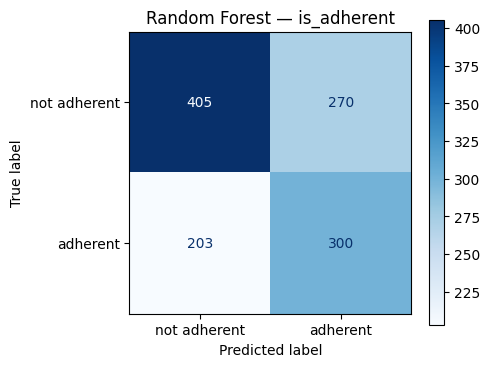

In [97]:
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.metrics import f1_score
import time

param_list = list(ParameterGrid(PARAM_GRID))
n_combos = len(param_list)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Starting grid search: {n_combos} param combos x {CV_FOLDS} folds = {n_combos * CV_FOLDS} fits\n")

best_score = -np.inf
best_params = None
results = []
t0 = time.perf_counter()

for i, params in enumerate(param_list, start=1):
    fold_scores = []
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        rf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        pred = rf.predict(X_train.iloc[val_idx])
        fold_scores.append(f1_score(y_train.iloc[val_idx], pred))

    mean_score = float(np.mean(fold_scores))
    results.append({**params, "mean_f1": mean_score})

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

    elapsed = time.perf_counter() - t0
    avg_per_combo = elapsed / i
    remaining = avg_per_combo * (n_combos - i)
    print(
        f"[{i}/{n_combos}] mean_f1={mean_score:.4f} | "
        f"elapsed={elapsed/60:.1f}m | ETA={remaining/60:.1f}m | "
        f"best_f1={best_score:.4f}"
    )

print(f"\nDone in {(time.perf_counter() - t0)/60:.1f} minutes")
print("Best params:", best_params)
print(f"Best CV f1: {best_score:.4f}")

# Refit best model on full training set, evaluate on holdout test
best_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\nClassification report (test set):")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["not adherent", "adherent"]).plot(ax=ax, cmap="Blues")
ax.set_title("Random Forest — is_adherent")
plt.tight_layout()
plt.show()


Starting grid search (AUC): 432 param combos x 5 folds = 2160 fits

[1/432] mean_auc=0.6071 | elapsed=0.0m | ETA=13.3m | best_auc=0.6071
[2/432] mean_auc=0.6092 | elapsed=0.1m | ETA=19.1m | best_auc=0.6092
[3/432] mean_auc=0.6106 | elapsed=0.2m | ETA=24.6m | best_auc=0.6106
[4/432] mean_auc=0.6197 | elapsed=0.2m | ETA=21.4m | best_auc=0.6197
[5/432] mean_auc=0.6215 | elapsed=0.3m | ETA=21.5m | best_auc=0.6215
[6/432] mean_auc=0.6211 | elapsed=0.3m | ETA=23.0m | best_auc=0.6215
[7/432] mean_auc=0.6229 | elapsed=0.3m | ETA=21.2m | best_auc=0.6229
[8/432] mean_auc=0.6237 | elapsed=0.4m | ETA=21.0m | best_auc=0.6237
[9/432] mean_auc=0.6252 | elapsed=0.5m | ETA=21.9m | best_auc=0.6252
[10/432] mean_auc=0.6328 | elapsed=0.5m | ETA=20.5m | best_auc=0.6328
[11/432] mean_auc=0.6334 | elapsed=0.5m | ETA=20.2m | best_auc=0.6334
[12/432] mean_auc=0.6335 | elapsed=0.6m | ETA=20.7m | best_auc=0.6335
[13/432] mean_auc=0.6325 | elapsed=0.6m | ETA=19.8m | best_auc=0.6335
[14/432] mean_auc=0.6336 | elap

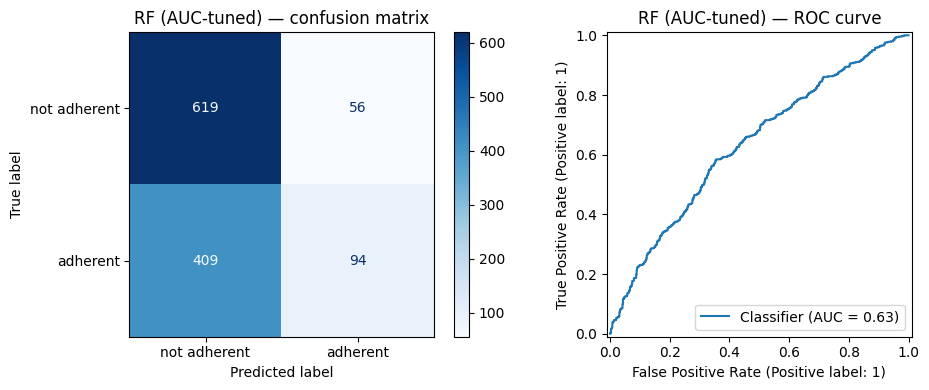

In [98]:
# Same grid search, tuned on ROC-AUC (with progress + ETA)
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import time

param_list = list(ParameterGrid(PARAM_GRID))
n_combos = len(param_list)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Starting grid search (AUC): {n_combos} param combos x {CV_FOLDS} folds = {n_combos * CV_FOLDS} fits\n")

best_score_auc = -np.inf
best_params_auc = None
results_auc = []
t0 = time.perf_counter()

for i, params in enumerate(param_list, start=1):
    fold_scores = []
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        rf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        proba = rf.predict_proba(X_train.iloc[val_idx])[:, 1]
        fold_scores.append(roc_auc_score(y_train.iloc[val_idx], proba))

    mean_score = float(np.mean(fold_scores))
    results_auc.append({**params, "mean_auc": mean_score})

    if mean_score > best_score_auc:
        best_score_auc = mean_score
        best_params_auc = params

    elapsed = time.perf_counter() - t0
    avg_per_combo = elapsed / i
    remaining = avg_per_combo * (n_combos - i)
    print(
        f"[{i}/{n_combos}] mean_auc={mean_score:.4f} | "
        f"elapsed={elapsed/60:.1f}m | ETA={remaining/60:.1f}m | "
        f"best_auc={best_score_auc:.4f}"
    )

print(f"\nDone in {(time.perf_counter() - t0)/60:.1f} minutes")
print("Best params (AUC):", best_params_auc)
print(f"Best CV AUC: {best_score_auc:.4f}")

# Refit best AUC model on full training set, evaluate on holdout test
best_rf_auc = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params_auc)
best_rf_auc.fit(X_train, y_train)
y_pred_auc = best_rf_auc.predict(X_test)
y_proba_auc = best_rf_auc.predict_proba(X_test)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test, y_proba_auc):.4f}")
print("\nClassification report (test set, AUC-tuned model):")
print(classification_report(y_test, y_pred_auc, digits=3))

cm_auc = confusion_matrix(y_test, y_pred_auc)
print("Confusion matrix (test set):")
print(cm_auc)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_auc, display_labels=["not adherent", "adherent"]).plot(
    ax=axes[0], cmap="Blues"
)
axes[0].set_title("RF (AUC-tuned) — confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba_auc, ax=axes[1])
axes[1].set_title("RF (AUC-tuned) — ROC curve")
plt.tight_layout()
plt.show()
